# Lesson 3 — Homework

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/djnzx/ida-practice-3d/blob/main/practice/3/3-homework.ipynb)

**Estimated time: 3-4 hours.**

## How to work through this

Each task gives a function signature and a docstring stating exactly what
to return. Replace `raise NotImplementedError` with your implementation;
the cell after it asserts the behaviour.

**A failing assert is information, not a grade.**

The written questions are marked and they carry the real learning
objective. Every one asks you to **run something both ways and explain
the difference** using numbers you produced. For each hyperparameter you
are asked about, say explicitly **which direction is underfitting, which
is overfitting, and what the metric does at each extreme**.

Every function you need is demonstrated in `3-practice.ipynb`, and each
task names the section.

## Before you submit

**Runtime → Restart and run all must complete without error** with every
assert passing. Then **File → Download → Download .ipynb**, rename the file to
`3-homework-results.ipynb`, and commit it to your fork under
`practice/3/`. Keep the outputs in the file; do not clear them.
The full procedure is in `practice/README.md` §8.

## 1. Setup

In [ ]:
import sys
import time

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

SEED = 20250919
rng = np.random.default_rng(SEED)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 130)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (7.0, 4.5)
plt.rcParams["figure.dpi"] = 110

print("python", sys.version.split()[0], "| scikit-learn", sklearn.__version__)

python 3.13.15 | scikit-learn 1.6.1


In [ ]:
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, KFold, GridSearchCV)
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score,
                             silhouette_score, adjusted_rand_score)

titanic = pd.read_csv(
    "https://raw.githubusercontent.com/rebrykgeorgi-glitch/ida-practice-3d-KB125/main/practice/datasets/titanic.csv"
)
wine = pd.read_csv(
    "https://raw.githubusercontent.com/rebrykgeorgi-glitch/ida-practice-3d-KB125/main/practice/datasets/wine.csv"
)
iris = pd.read_csv(
    "https://raw.githubusercontent.com/rebrykgeorgi-glitch/ida-practice-3d-KB125/main/practice/datasets/iris.csv"
)
bikes = pd.read_csv(
    "https://raw.githubusercontent.com/rebrykgeorgi-glitch/ida-practice-3d-KB125/main/practice/datasets/bike_sharing_hourly.csv"
)

print("titanic", titanic.shape, "| wine", wine.shape, "| iris", iris.shape, "| bikes", bikes.shape)

titanic (891, 12) | wine (178, 14) | iris (150, 6) | bikes (17379, 17)


## 2. Task 1 — Regression metrics from their definitions

Mechanical. Do not call scikit-learn's metric functions; build them from
the errors.

*see Practice 3 §4.2*

In [ ]:
def regression_metrics(y_true, y_pred):
    """Return a dict with keys 'mse', 'rmse', 'mae', 'r2'.

        mse  = mean of the squared errors
        rmse = square root of mse
        mae  = mean of the absolute errors
        r2   = 1 - (sum of squared errors) / (sum of squared deviations
               of y_true from its own mean)

    Return Python/NumPy floats. Do not import from sklearn.metrics.
    """
    errors = y_true - y_pred

    mse = np.mean(errors ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(errors))

    ss_res = np.sum(errors ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)

    r2 = 1 - ss_res / ss_tot

    return {
        "mse": mse,
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
    }

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

_truth = np.array([10.0, 20.0, 30.0, 40.0, 50.0])
_guess = np.array([12.0, 18.0, 33.0, 39.0, 54.0])
_m = regression_metrics(_truth, _guess)

assert set(_m) == {"mse", "rmse", "mae", "r2"}
assert np.isclose(_m["mse"], mean_squared_error(_truth, _guess)), f"mse wrong: {_m['mse']}"
assert np.isclose(_m["rmse"], np.sqrt(mean_squared_error(_truth, _guess)))
assert np.isclose(_m["mae"], mean_absolute_error(_truth, _guess)), f"mae wrong: {_m['mae']}"
assert np.isclose(_m["r2"], r2_score(_truth, _guess)), f"r2 wrong: {_m['r2']}"

# A perfect prediction: zero error, R^2 exactly 1.
_perfect = regression_metrics(_truth, _truth)
assert np.isclose(_perfect["mse"], 0.0) and np.isclose(_perfect["r2"], 1.0)

# Predicting the mean every time gives R^2 of exactly 0, by construction.
_mean_only = regression_metrics(_truth, np.full_like(_truth, _truth.mean()))
assert np.isclose(_mean_only["r2"], 0.0), \
    f"always predicting the mean must give R^2 = 0, you got {_mean_only['r2']}"

# RMSE >= MAE always, with equality only when every error has the same size.
_noisy = rng.normal(0, 5, 500)
_m2 = regression_metrics(_noisy, np.zeros(500))
assert _m2["rmse"] >= _m2["mae"]

print({k: round(v, 4) for k, v in _m.items()})
print("Task 1 passed.")

{'mse': np.float64(6.8), 'rmse': np.float64(2.6077), 'mae': np.float64(2.4), 'r2': np.float64(0.966)}
Task 1 passed.


### Question 1 — reading the metrics

Fit a `LinearRegression` to the bicycle data using `temp`, `hum` and
`windspeed` to predict `cnt`, on a 75/25 split with `random_state=SEED`.
Report all four metrics on the test set with your `regression_metrics`.

**(a)** Explain what RMSE means **in bicycles** for this model. Then
explain why the MSE figure cannot be interpreted the same way.

**(b)** Compute the ratio RMSE / MAE. What does a ratio well above 1 tell
you about the distribution of the errors? Find the ten worst-predicted
hours and say what they have in common.

**(c)** Your R² is low. Add the one-hot encoded `hr` column and refit.
How much does R² improve? Explain, referring to Practice 2 §8.4, why hour
of day carries so much of the signal and why it had to be one-hot encoded
rather than used as an integer.

In [ ]:
# =========================================================
# Question 1 — reading the regression metrics
# =========================================================

y = bikes["cnt"]

# Use exactly the same train/test rows for both models
train_idx, test_idx = train_test_split(
    bikes.index,
    test_size=0.25,
    random_state=SEED
)

# ---------------------------------------------------------
# (a) Basic model: temp + hum + windspeed
# ---------------------------------------------------------

X_basic = bikes[["temp", "hum", "windspeed"]]

X_train = X_basic.loc[train_idx]
X_test = X_basic.loc[test_idx]
y_train = y.loc[train_idx]
y_test = y.loc[test_idx]

basic_model = LinearRegression()
basic_model.fit(X_train, y_train)

basic_pred = basic_model.predict(X_test)

basic_metrics = regression_metrics(
    y_test.to_numpy(),
    basic_pred
)

print("BASIC MODEL: temp + hum + windspeed")
for name, value in basic_metrics.items():
    print(f"{name:5s}: {value:.4f}")


# ---------------------------------------------------------
# (b) RMSE / MAE and ten worst predictions
# ---------------------------------------------------------

ratio = basic_metrics["rmse"] / basic_metrics["mae"]

print(f"\nRMSE / MAE ratio: {ratio:.4f}")

worst = bikes.loc[
    test_idx,
    ["dteday", "hr", "workingday", "weathersit", "cnt"]
].copy()

worst["predicted"] = basic_pred
worst["error"] = worst["cnt"] - worst["predicted"]
worst["abs_error"] = worst["error"].abs()

worst10 = worst.sort_values(
    "abs_error",
    ascending=False
).head(10)

print("\nTen worst-predicted test hours:")
print(
    worst10[
        [
            "dteday",
            "hr",
            "workingday",
            "weathersit",
            "cnt",
            "predicted",
            "error",
            "abs_error",
        ]
    ].round(2).to_string(index=False)
)

print("\nHours among the ten worst predictions:")
print(worst10["hr"].value_counts().sort_index())

print("\nWorking-day status among the ten worst predictions:")
print(worst10["workingday"].value_counts().sort_index())


# ---------------------------------------------------------
# (c) Add one-hot encoded hour
# ---------------------------------------------------------

X_hour = pd.get_dummies(
    bikes[["temp", "hum", "windspeed", "hr"]],
    columns=["hr"],
    dtype=float
)

X_hour_train = X_hour.loc[train_idx]
X_hour_test = X_hour.loc[test_idx]

hour_model = LinearRegression()
hour_model.fit(X_hour_train, y_train)

hour_pred = hour_model.predict(X_hour_test)

hour_metrics = regression_metrics(
    y_test.to_numpy(),
    hour_pred
)

print("\nMODEL WITH ONE-HOT ENCODED HOUR:")
for name, value in hour_metrics.items():
    print(f"{name:5s}: {value:.4f}")

r2_improvement = (
    hour_metrics["r2"] - basic_metrics["r2"]
)

print(
    f"\nR2 improvement: "
    f"{basic_metrics['r2']:.4f} -> "
    f"{hour_metrics['r2']:.4f} "
    f"(+{r2_improvement:.4f})"
)

BASIC MODEL: temp + hum + windspeed
mse  : 25094.1254
rmse : 158.4113
mae  : 118.9047
r2   : 0.2511

RMSE / MAE ratio: 1.3323

Ten worst-predicted test hours:
    dteday  hr  workingday  weathersit  cnt  predicted    error  abs_error
2012-09-27  17           1           2  905   232.4200 672.5800   672.5800
2012-10-03  17           1           1  917   254.7700 662.2300   662.2300
2012-10-24   8           1           2  801   141.3300 659.6700   659.6700
2012-09-26   8           1           1  838   185.2900 652.7100   652.7100
2012-10-03   8           1           2  809   163.7200 645.2800   645.2800
2012-10-23  17           1           1  938   313.5300 624.4700   624.4700
2012-04-20   8           1           1  700    81.0900 618.9100   618.9100
2012-08-20  17           1           1  893   276.9700 616.0300   616.0300
2012-10-23   8           1           2  761   149.7400 611.2600   611.2600
2012-10-12   8           1           1  745   138.0400 606.9600   606.9600

Hours among the

**(a)** The basic linear regression model using `temp`, `hum` and `windspeed` produced MSE = `25094.1254`, RMSE = `158.4113`, MAE = `118.9047`, and R² = `0.2511` on the test set.

The RMSE of `158.4113` means that the model's prediction errors are typically on the order of about 158 bicycle rentals per hour, with larger errors receiving extra weight because the errors are squared before averaging. RMSE is expressed in the same units as the target, so it can be interpreted directly in bicycles.

The MSE value of `25094.1254` cannot be interpreted in the same way because its unit is bicycles squared. Squaring is useful mathematically because it penalises large errors strongly, but the resulting number is not directly meaningful as a number of bicycle rentals.

**(b)** The ratio RMSE / MAE is `1.3323`. Because RMSE gives more weight to large errors than MAE, a ratio noticeably above 1 indicates that the error distribution contains some relatively large prediction errors rather than all errors having similar magnitude.

The ten worst predictions confirm this. All ten are working days, and all occur at either 08:00 or 17:00: six occur at 08:00 and four at 17:00. These are the main commuting hours. Their observed demand is very high, between 700 and 938 rentals, while the model predicts much smaller values, producing under-prediction errors of approximately 607 to 673 bicycles.

The weather conditions of these observations are only categories 1 or 2, so the large errors are not primarily associated with extreme weather. Instead, the common feature is the commuter peak on working days. The basic model does not contain hour of day or working-day timing information, so it cannot represent these sharp demand peaks using only temperature, humidity and wind speed.

**(c)** After adding a one-hot encoded `hr` variable, R² increased from `0.2511` to `0.6052`, an absolute improvement of `0.3541`. RMSE also fell from `158.4113` to `115.0148`, and MAE fell from `118.9047` to `82.3729`. Therefore, hour of day contains a large amount of predictive information that was missing from the weather-only model.

This agrees with the hourly demand profile from Practice 2: bicycle demand has strong commuting peaks around 08:00 and 17:00–18:00 rather than increasing or decreasing smoothly throughout the day. Using `hr` as a single integer would impose an inappropriate numeric structure, suggesting that the effect changes linearly with hour and that the numerical distance between hours has direct meaning. It would also treat 23:00 and 00:00 as far apart even though they are adjacent in time.

One-hot encoding avoids this assumption by giving each hour its own indicator variable. The regression model can therefore learn a separate effect for each hour and represent the non-linear morning and evening demand peaks directly.

## 3. Task 2 — Classification metrics from the confusion matrix

Mechanical. Again, build them by hand.

*see Practice 3 §9.2 and §9.3*

In [ ]:
def binary_metrics(y_true, y_pred):
    """Return a dict of binary classification metrics computed from the
    four cells of the confusion matrix.

    Keys, exactly these seven:
        'tn', 'fp', 'fn', 'tp'   the four counts, as ints
        'precision'  TP / (TP + FP)
        'recall'     TP / (TP + FN)
        'f1'         harmonic mean of precision and recall

    The positive class is 1. If a denominator is zero, return 0.0 for
    that metric rather than raising.
    """

    tn = int(np.sum((y_true == 0) & (y_pred == 0)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))
    tp = int(np.sum((y_true == 1) & (y_pred == 1)))

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0

    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )

    return {
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

In [ ]:
_y_true = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
_y_pred = np.array([0, 0, 0, 1, 1, 1, 1, 0, 0, 0])
_b = binary_metrics(_y_true, _y_pred)

assert set(_b) == {"tn", "fp", "fn", "tp", "precision", "recall", "f1"}
assert (_b["tn"], _b["fp"], _b["fn"], _b["tp"]) == (3, 1, 3, 3), \
    f"counts wrong: TN={_b['tn']} FP={_b['fp']} FN={_b['fn']} TP={_b['tp']}"
assert np.isclose(_b["precision"], 3 / 4)
assert np.isclose(_b["recall"], 3 / 6)
assert np.isclose(_b["f1"], 2 * 0.75 * 0.5 / 1.25)

# Must agree with sklearn's confusion_matrix, which orders cells the same way.
_sk_tn, _sk_fp, _sk_fn, _sk_tp = confusion_matrix(_y_true, _y_pred).ravel()
assert (_b["tn"], _b["fp"], _b["fn"], _b["tp"]) == (_sk_tn, _sk_fp, _sk_fn, _sk_tp)

# A model that never predicts the positive class: recall 0, no division error.
_never = binary_metrics(_y_true, np.zeros(10, dtype=int))
assert _never["recall"] == 0.0 and _never["precision"] == 0.0 and _never["f1"] == 0.0

print(_b)
print("Task 2 passed.")

{'tn': 3, 'fp': 1, 'fn': 3, 'tp': 3, 'precision': 0.75, 'recall': 0.5, 'f1': 0.6}
Task 2 passed.


## 4. Task 3 — The baseline you must state first

Mechanical.

*see Practice 3 §9.4*

In [ ]:
def baseline_and_model(y_true, y_pred):
    """Compare a model against the majority-class baseline.

    The baseline predicts the most frequent class in `y_true` for every
    row. (Using y_true to find the majority class is a simplification for
    this exercise; in Practice 3 §15 the baseline is fitted on the
    training set, which is the correct procedure.)

    Return a dict with exactly these four keys:
        'majority_class'    the most frequent label in y_true, as an int
        'baseline_accuracy' accuracy of always predicting it
        'model_accuracy'    accuracy of y_pred
        'improvement'       model_accuracy - baseline_accuracy
    """

    values, counts = np.unique(y_true, return_counts=True)

    majority_class = int(values[np.argmax(counts)])

    baseline_pred = np.full(
        len(y_true),
        majority_class
    )

    baseline_accuracy = np.mean(
        baseline_pred == y_true
    )

    model_accuracy = np.mean(
        y_pred == y_true
    )

    improvement = (
        model_accuracy - baseline_accuracy
    )

    return {
        "majority_class": majority_class,
        "baseline_accuracy": baseline_accuracy,
        "model_accuracy": model_accuracy,
        "improvement": improvement,
    }

In [ ]:
_imbalanced = np.array([0] * 95 + [1] * 5)
_always_zero = np.zeros(100, dtype=int)
_r = baseline_and_model(_imbalanced, _always_zero)

assert _r["majority_class"] == 0
assert np.isclose(_r["baseline_accuracy"], 0.95)
assert np.isclose(_r["model_accuracy"], 0.95)
assert np.isclose(_r["improvement"], 0.0), \
    "a model that only predicts the majority class improves on the baseline by exactly 0"

_titanic_r = baseline_and_model(titanic["Survived"].values, np.zeros(len(titanic), dtype=int))
assert _titanic_r["majority_class"] == 0
assert np.isclose(_titanic_r["baseline_accuracy"], 0.6162, atol=1e-3), \
    f"Titanic's majority-class baseline is 0.6162, you got {_titanic_r['baseline_accuracy']}"

print(f"On a 95/5 split, a model with 95% accuracy has improved by "
      f"{_r['improvement']:.4f} over doing nothing.")
print("Task 3 passed.")

On a 95/5 split, a model with 95% accuracy has improved by 0.0000 over doing nothing.
Task 3 passed.


## 5. Task 4 — A leak-free pipeline

Applied. The scaler must be re-fitted inside every fold.

*see Practice 3 §6.3*

In [ ]:
def compare_leak(X, y, cv):
    """Quantify the leak from scaling before cross-validating.

    Build two cross-validated accuracy estimates of an
    SVC(kernel='rbf', C=1.0, gamma='scale', random_state=SEED):

      'leaky'   scale X with a StandardScaler fitted on ALL of X, then
                cross-validate the bare SVC on the scaled array
      'clean'   cross-validate a Pipeline of StandardScaler then SVC,
                so the scaler is re-fitted on each fold's training rows

    Use the `cv` object passed in for both, and scoring='accuracy'.

    Return a dict with four keys:
        'leaky'           mean accuracy of the leaky procedure, a float
        'clean'           mean accuracy of the clean procedure, a float
        'difference'      leaky - clean
        'clean_estimator' the (unfitted) estimator object you passed to
                          cross_val_score for the clean path
    """

    # Leaky path: scaler sees the entire dataset before CV
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    leaky_estimator = SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        random_state=SEED
    )

    leaky_scores = cross_val_score(
        leaky_estimator,
        X_scaled,
        y,
        cv=cv,
        scoring="accuracy"
    )

    # Clean path: scaler is re-fitted inside each CV fold
    clean_estimator = Pipeline([
        ("standardscaler", StandardScaler()),
        ("svc", SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",
            random_state=SEED
        ))
    ])

    clean_scores = cross_val_score(
        clean_estimator,
        X,
        y,
        cv=cv,
        scoring="accuracy"
    )

    leaky_mean = float(leaky_scores.mean())
    clean_mean = float(clean_scores.mean())

    return {
        "leaky": leaky_mean,
        "clean": clean_mean,
        "difference": leaky_mean - clean_mean,
        "clean_estimator": clean_estimator,
    }

In [ ]:
_wine_features = [c for c in wine.columns if c != "target"]
_X_wine = wine[_wine_features].values
_y_wine = wine["target"].values
_cv = StratifiedKFold(5, shuffle=True, random_state=SEED)

_leak = compare_leak(_X_wine, _y_wine, _cv)

assert set(_leak) == {"leaky", "clean", "difference", "clean_estimator"}
assert 0.9 < _leak["clean"] < 1.0, f"the clean score looks wrong: {_leak['clean']}"
assert np.isclose(_leak["difference"], _leak["leaky"] - _leak["clean"])

# The clean path must go through a Pipeline: that is the whole point, and it
# is checkable directly rather than through the score.
_estimator = _leak["clean_estimator"]
assert isinstance(_estimator, Pipeline), \
    f"the clean path must use a Pipeline, you passed a {type(_estimator).__name__}"
_step_types = [type(step).__name__ for _, step in _estimator.steps]
assert _step_types == ["StandardScaler", "SVC"], \
    f"expected StandardScaler then SVC, got {_step_types}"
# cross_val_score clones its estimator, so the object you passed in should
# still be unfitted. A fitted SVC carries a support_ attribute (Practice 3
# section 2: a trailing underscore means fit set it).
assert not hasattr(_estimator.named_steps["svc"], "support_"), \
    "return the estimator you passed to cross_val_score, not one you fitted yourself"

print(f"wine  leaky {_leak['leaky']:.4f}  clean {_leak['clean']:.4f}  "
      f"difference {_leak['difference']:+.4f}")
print("The two agree to four decimals here. Question 2(c) asks why, and when they would not.")
print("Task 4 passed.")

wine  leaky 0.9833  clean 0.9833  difference +0.0000
The two agree to four decimals here. Question 2(c) asks why, and when they would not.
Task 4 passed.


### Question 2 — folds and leakage

**(a)** Re-run `compare_leak` on the wine data with `cv` set to
`StratifiedKFold(k)` for k = 2, 5, 10 and `len(y)` (leave-one-out).
Tabulate the clean score and the leak at each. **Which direction does the
number of folds push the leak, and why?** Think about how much of the
data each fold's scaler sees.

**(b)** More folds means each model trains on more data and you fit more
models. State the trade-off in terms of bias, variance of the estimate,
and compute cost. Why is 5 or 10 the usual choice rather than
leave-one-out?

**(c)** Practice 3 §6.3 showed the leak reaching 27 percentage points with
a feature selector on pure noise, and essentially zero with a scaler on
wine. State the general rule that predicts which case you are in.

In [ ]:
# =========================================================
# Question 2 — folds and leakage
# =========================================================

fold_settings = [
    ("2", StratifiedKFold(
        n_splits=2,
        shuffle=True,
        random_state=SEED
    )),
    ("5", StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=SEED
    )),
    ("10", StratifiedKFold(
        n_splits=10,
        shuffle=True,
        random_state=SEED
    )),
    (
        f"{len(_y_wine)} (leave-one-out)",
        KFold(n_splits=len(_y_wine))
    ),
]

rows = []

for label, cv_object in fold_settings:
    result = compare_leak(
        _X_wine,
        _y_wine,
        cv_object
    )

    n_splits = cv_object.get_n_splits(
        _X_wine,
        _y_wine
    )

    train_fraction = (
        n_splits - 1
    ) / n_splits

    rows.append({
        "folds": label,
        "train_fraction": train_fraction,
        "leaky": result["leaky"],
        "clean": result["clean"],
        "leak": result["difference"],
    })

fold_results = pd.DataFrame(rows)

print("Cross-validation and leakage:")
print(
    fold_results.to_string(
        index=False,
        formatters={
            "train_fraction": lambda x: f"{x:.4f}",
            "leaky": lambda x: f"{x:.4f}",
            "clean": lambda x: f"{x:.4f}",
            "leak": lambda x: f"{x:+.4f}",
        }
    )
)

Cross-validation and leakage:
              folds train_fraction  leaky  clean    leak
                  2         0.5000 0.9719 0.9775 -0.0056
                  5         0.8000 0.9833 0.9833 +0.0000
                 10         0.9000 0.9833 0.9833 +0.0000
178 (leave-one-out)         0.9944 0.9831 0.9831 +0.0000


**(a)** The effect of scaling leakage is extremely small on the wine data. With 2 folds, the leaky procedure obtained an accuracy of `0.9719`, while the clean pipeline obtained `0.9775`, giving a difference of `-0.0056`. With 5 folds and 10 folds, both procedures produced `0.9833`, so the measured difference was `0.0000`. Under leave-one-out cross-validation, both scores were approximately `0.9831`, again giving essentially zero difference.

As the number of folds increases, each training fold contains a larger fraction of the complete dataset: 50% with 2 folds, 80% with 5 folds, 90% with 10 folds, and approximately 99.44% under leave-one-out. Therefore, the mean and standard deviation learned by a scaler fitted only on a training fold become increasingly similar to those learned from the whole dataset. This pushes the difference between the leaky and clean procedures towards zero.

The `-0.0056` result with 2 folds does not mean that leakage is beneficial in the opposite direction. Leakage does not guarantee a higher measured score in every finite sample; here the difference is small enough that fold composition and the discrete number of classification errors can determine its sign. The important issue is that the leaky procedure is methodologically invalid because validation observations influenced preprocessing.

For the leave-one-out case I used 178 folds, so each validation set contained one observation and each training set contained the other 177 observations.

**(b)** Increasing the number of folds gives each fitted model a larger training set, which generally reduces the bias of the cross-validation estimate relative to the performance of a model trained on the full dataset. However, the validation sets become smaller, and the fitted training sets across folds overlap very strongly. At the leave-one-out extreme this can give a relatively high-variance estimate: individual predictions can have a large influence, while the training sets are almost identical to one another.

The computational cost also increases approximately with the number of folds. Two-fold cross-validation requires two model fits per procedure, 5-fold requires five, 10-fold requires ten, and leave-one-out on this dataset requires 178 fits per procedure. In this experiment `compare_leak` evaluates both a leaky and a clean procedure, so leave-one-out requires 356 cross-validation model fits in total.

For these reasons, 5-fold or 10-fold cross-validation is commonly preferred. It gives a useful compromise between bias, variance and computational cost. Leave-one-out trains on almost the full dataset in every fold, but usually costs much more without providing a correspondingly better estimate.

**(c)** The general rule is that the size of leakage depends on how much information the preprocessing step learns from the data, especially whether it learns anything about the relationship between the features and the target.

`StandardScaler` learns only a mean and standard deviation for each feature. On the 178 well-behaved wine observations, these quantities change very little when a validation fold is removed, so fitting the scaler on the full dataset produces almost no visible change in accuracy.

A feature-selection procedure is much more dangerous. If it searches through thousands of features and chooses those most associated with the target using the complete dataset, it can exploit chance relationships that involve the validation observations themselves. Practice 3 §6.3 showed that this produced leakage of about 27 percentage points even when the features contained only noise.

Therefore, the practical rule is that every preprocessing step that learns anything from the data must be placed inside the `Pipeline`, regardless of whether the measured leakage happens to be small in one particular dataset.

## 6. Task 5 — The bias-variance curve

Applied.

*see Practice 3 §7.3*

In [ ]:
def degree_sweep(x, y, degrees, cv):
    """Fit a polynomial regression at each degree and record both errors.

    For each degree d in `degrees`, build
    make_pipeline(PolynomialFeatures(degree=d), LinearRegression()).

        train_mse  fit on ALL of (x, y), then the MSE of its predictions
                   on that same data
        cv_mse     the mean of -cross_val_score(..., cv=cv,
                   scoring='neg_mean_squared_error')

    `x` is 1-D; reshape it for scikit-learn (Practice 1 §3.5).

    Return a DataFrame indexed by degree with columns 'train_mse' and
    'cv_mse', in that order.
    """

    X = np.asarray(x).reshape(-1, 1)
    y = np.asarray(y)

    rows = []

    for degree in degrees:
        model = make_pipeline(
            PolynomialFeatures(degree=degree),
            LinearRegression()
        )

        # Training error
        model.fit(X, y)
        train_pred = model.predict(X)

        train_mse = np.mean(
            (y - train_pred) ** 2
        )

        # Cross-validation error
        cv_scores = cross_val_score(
            model,
            X,
            y,
            cv=cv,
            scoring="neg_mean_squared_error"
        )

        cv_mse = -cv_scores.mean()

        rows.append({
            "degree": degree,
            "train_mse": float(train_mse),
            "cv_mse": float(cv_mse),
        })

    result = pd.DataFrame(rows).set_index("degree")

    return result[["train_mse", "cv_mse"]]

In [ ]:
_poly_rng = np.random.default_rng(SEED)
_x_poly = _poly_rng.uniform(-3, 3, 50)
_y_poly = (_x_poly ** 4 - 3 * _x_poly ** 2 + _x_poly + 5) + _poly_rng.normal(0, 12.0, 50)

_sweep = degree_sweep(_x_poly, _y_poly, range(1, 16), KFold(5, shuffle=True, random_state=SEED))

assert list(_sweep.columns) == ["train_mse", "cv_mse"]
assert len(_sweep) == 15

# Training error must fall (weakly) as the model gains flexibility.
_train = _sweep["train_mse"].values
assert np.all(np.diff(_train) < 1e-6), \
    "training MSE must be non-increasing in the degree; a degree-d model can do anything a degree-(d-1) model can"

# Validation error must NOT be monotone: it has a minimum and then rises.
assert _sweep["cv_mse"].idxmin() < 15, "validation error should not be minimised at the highest degree"
assert _sweep.loc[15, "cv_mse"] > _sweep["cv_mse"].min() * 10, \
    "a degree-15 polynomial on 50 noisy points should overfit badly"
assert _sweep.loc[1, "cv_mse"] > _sweep["cv_mse"].min() * 2, \
    "a straight line should underfit a quartic badly"

print(_sweep.round(2).to_string())
print(f"\nbest degree by cross-validation: {_sweep['cv_mse'].idxmin()}")
print("Task 5 passed.")

        train_mse      cv_mse
degree                       
1        397.8800    468.4700
2        146.8600    165.9000
3        144.4100    168.8300
4         82.1600    111.8500
5         81.3900    120.0800
6         81.1400    128.5300
7         81.0700    157.3500
8         73.3200    113.4500
9         70.4200    115.2500
10        69.2800    118.8700
11        68.6700    171.4900
12        68.4400  1,699.0900
13        68.4400 19,405.7200
14        66.2600 91,266.7500
15        65.9500 28,992.7500

best degree by cross-validation: 4
Task 5 passed.


### Question 3 — polynomial degree

Plot both columns of your sweep on one axes with a log y scale.

**(a)** Identify the underfitting region and the overfitting region by
degree. For each, say what the **training** error is doing and what the
**validation** error is doing, and explain why the gap between them is
the diagnostic rather than either curve alone.

**(b)** At the extremes: what does training MSE tend to as the degree
approaches the number of data points, and why? What does validation MSE
do?

**(c)** Re-run the sweep with 500 points instead of 50, same noise. Which
degree wins now, and how far does the overfitting region move? State the
general relationship between the amount of data and the model complexity
you can afford.

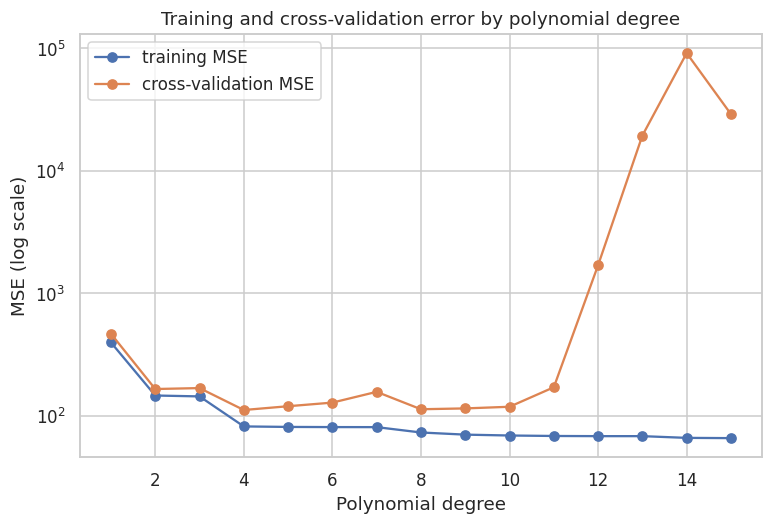

500-point sweep:
        train_mse   cv_mse
degree                    
1        339.2000 341.5000
2        176.1400 178.2000
3        176.1300 179.7500
4        137.2900 140.5000
5        136.8800 140.6700
6        136.5100 141.0200
7        136.2600 141.2000
8        136.1500 143.0700
9        136.0600 143.1600
10       135.6100 143.7200
11       135.4800 144.7600
12       135.4600 148.3100
13       135.4100 158.6400
14       135.4100 184.2100
15       134.8000 168.0900

Best degree with 50 points : 4
Best degree with 500 points: 4


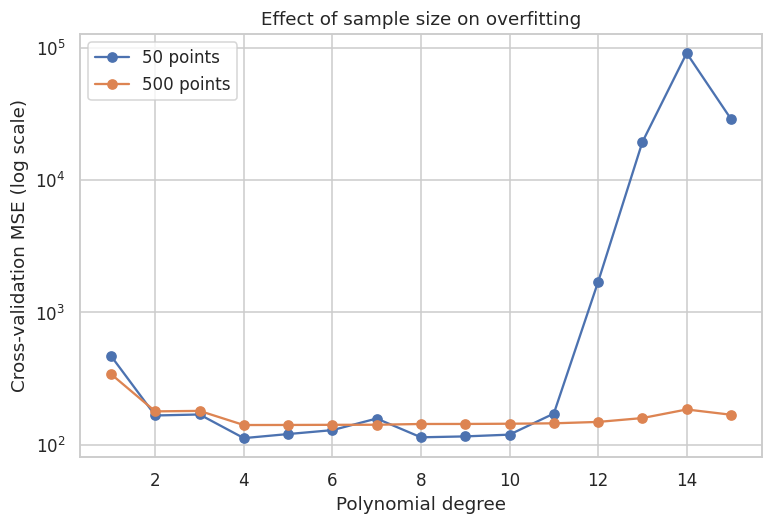

In [ ]:
# =========================================================
# Question 3 — polynomial degree
# =========================================================

# ---------------------------------------------------------
# Plot the 50-point sweep
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    _sweep.index,
    _sweep["train_mse"],
    marker="o",
    label="training MSE"
)

ax.plot(
    _sweep.index,
    _sweep["cv_mse"],
    marker="o",
    label="cross-validation MSE"
)

ax.set_yscale("log")
ax.set_xlabel("Polynomial degree")
ax.set_ylabel("MSE (log scale)")
ax.set_title("Training and cross-validation error by polynomial degree")
ax.legend()

plt.show()


# ---------------------------------------------------------
# Repeat with 500 points and the same underlying function
# and the same noise standard deviation
# ---------------------------------------------------------

_rng_500 = np.random.default_rng(SEED)

_x_500 = _rng_500.uniform(-3, 3, 500)

_y_500 = (
    _x_500 ** 4
    - 3 * _x_500 ** 2
    + _x_500
    + 5
    + _rng_500.normal(0, 12.0, 500)
)

_sweep_500 = degree_sweep(
    _x_500,
    _y_500,
    range(1, 16),
    KFold(5, shuffle=True, random_state=SEED)
)

print("500-point sweep:")
print(_sweep_500.round(2).to_string())

print(
    "\nBest degree with 50 points :",
    _sweep["cv_mse"].idxmin()
)

print(
    "Best degree with 500 points:",
    _sweep_500["cv_mse"].idxmin()
)


# ---------------------------------------------------------
# Compare both CV curves
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    _sweep.index,
    _sweep["cv_mse"],
    marker="o",
    label="50 points"
)

ax.plot(
    _sweep_500.index,
    _sweep_500["cv_mse"],
    marker="o",
    label="500 points"
)

ax.set_yscale("log")
ax.set_xlabel("Polynomial degree")
ax.set_ylabel("Cross-validation MSE (log scale)")
ax.set_title("Effect of sample size on overfitting")
ax.legend()

plt.show()

**(a)** With 50 observations, the low-degree models show underfitting. Degree 1 has a training MSE of `397.88` and a cross-validation MSE of `468.47`, so both errors are high. Degrees 2 and 3 improve substantially, but their validation MSE values (`165.99` and `168.83`) are still clearly above the minimum. Degree 4 gives the lowest cross-validation MSE, `111.85`, and therefore provides the best bias-variance compromise in this experiment.

As the degree increases beyond 4, the training MSE continues to decrease, from `82.16` at degree 4 to `65.95` at degree 15. The validation error, however, does not continue to improve. It becomes increasingly unstable and rises dramatically at high degrees: `171.49` at degree 11, `1699.09` at degree 12, `19405.72` at degree 13, and `91266.75` at degree 14. Thus, the high-degree region, especially degrees 11–15, is clear overfitting.

The gap between training and validation error is the important diagnostic. A high training error together with a high validation error indicates underfitting: the model cannot even represent the training data well. A low training error together with a much larger validation error indicates overfitting: the model fits the training sample very closely but generalises poorly. Training error alone is not sufficient because it normally decreases as model complexity increases, while a high validation error alone does not tell us whether the problem is too little or too much model flexibility.

**(b)** As the polynomial degree approaches the number of training observations minus one, the training MSE can tend toward zero. With sufficiently many polynomial parameters and distinct input values, a polynomial can interpolate the training observations almost exactly, including the random noise.

That does not imply good prediction. At this extreme, the fitted curve has very high variance and becomes extremely sensitive to the particular training sample. Consequently, the validation MSE tends to increase sharply and can become extremely large. The 50-point experiment already shows the beginning of this behaviour: while training MSE continues to fall, cross-validation MSE increases by orders of magnitude at degrees 12–15.

**(c)** With 500 observations, degree 4 is still the cross-validation winner. Its training MSE is `137.29` and its validation MSE is `140.50`. This is expected because the data-generating relationship is quartic, so degree 4 has enough flexibility to represent the true systematic structure without requiring unnecessary additional parameters.

The important difference is what happens at higher degrees. With only 50 points, severe overfitting appears around degrees 11–12 and then becomes extreme, with validation MSE reaching `91266.75` at degree 14. With 500 points, the validation error remains comparatively stable through much higher degrees: it is only `144.76` at degree 11 and `148.31` at degree 12. It rises more noticeably at degrees 13–15, reaching `158.64`, `184.21`, and `168.09`, but this deterioration is far smaller than in the 50-point experiment.

Therefore, increasing the amount of data moves the severe overfitting region toward greater model complexity and makes overfitting at a fixed degree much less pronounced. More observations constrain the additional parameters and reduce variance. In general, larger datasets can support more flexible models, whereas a highly flexible model fitted to a small noisy dataset is much more likely to learn sampling noise rather than the underlying relationship.

## 7. Task 6 — Tune a tree honestly

Applied.

*see Practice 3 §8.3 and §6.4*

In [ ]:
def tune_tree(
    X,
    y,
    cv,
    depths=(1, 2, 3, 4, 5, 6, 8, 10, None),
    criteria=("gini", "entropy")
):
    """Grid-search a DecisionTreeClassifier over max_depth and criterion.

    Use GridSearchCV with the given `cv`, scoring='accuracy', refit=True,
    and DecisionTreeClassifier(random_state=SEED).

    Return a dict with exactly these four keys:
        'best_depth'      the chosen max_depth (may be None)
        'best_criterion'  the chosen criterion, a string
        'best_cv_score'   the best cross-validated accuracy, a float
        'search'          the fitted GridSearchCV object
    """

    tree = DecisionTreeClassifier(
        random_state=SEED
    )

    param_grid = {
        "max_depth": list(depths),
        "criterion": list(criteria),
    }

    search = GridSearchCV(
        estimator=tree,
        param_grid=param_grid,
        cv=cv,
        scoring="accuracy",
        refit=True
    )

    search.fit(X, y)

    return {
        "best_depth": search.best_params_["max_depth"],
        "best_criterion": search.best_params_["criterion"],
        "best_cv_score": float(search.best_score_),
        "search": search,
    }

In [ ]:
_X_iris = iris.drop(columns=["Id", "Species"]).values
_y_iris = iris["Species"].values
_iris_cv = StratifiedKFold(5, shuffle=True, random_state=SEED)

_tuned = tune_tree(_X_iris, _y_iris, _iris_cv)

assert set(_tuned) == {"best_depth", "best_criterion", "best_cv_score", "search"}
assert _tuned["best_criterion"] in ("gini", "entropy")
assert 0.9 < _tuned["best_cv_score"] <= 1.0, f"CV score looks wrong: {_tuned['best_cv_score']}"
assert len(_tuned["search"].cv_results_["params"]) == 18, \
    "9 depths x 2 criteria = 18 combinations"

# A depth-1 tree cannot separate three classes: it has only two leaves.
_depth1 = cross_val_score(DecisionTreeClassifier(max_depth=1, random_state=SEED),
                          _X_iris, _y_iris, cv=_iris_cv).mean()
assert _depth1 < 0.75, f"a two-leaf tree should not classify three classes well, got {_depth1:.4f}"
assert _tuned["best_cv_score"] > _depth1, "tuning should beat the depth-1 stump"

# The chosen tree must not be the fully grown one if a shallower one ties it.
_full = cross_val_score(DecisionTreeClassifier(random_state=SEED), _X_iris, _y_iris, cv=_iris_cv).mean()
print(f"best: max_depth={_tuned['best_depth']}, criterion={_tuned['best_criterion']}, "
      f"CV {_tuned['best_cv_score']:.4f}")
print(f"depth-1 stump CV {_depth1:.4f}   fully grown tree CV {_full:.4f}")
print("Task 6 passed.")

best: max_depth=4, criterion=gini, CV 0.9333
depth-1 stump CV 0.6667   fully grown tree CV 0.9333
Task 6 passed.


### Question 4 — tree hyperparameters

**(a)** Using `_tuned['search'].cv_results_`, tabulate the CV score at
every `max_depth` for both criteria. **Which direction is underfitting
and which is overfitting?** Give the depth at which each begins for this
data.

**(b)** `gini` and `criterion='entropy'` gave nearly the same answer.
Explain what each measures and why they rarely disagree. Construct or
describe a situation in which they might.

**(c)** Fit a tree with `max_depth=None` and report its **training**
accuracy. Explain in one sentence why that number is uninformative, and
name the other hyperparameter from Practice 3 §8.3 that limits the same
behaviour from a different direction.

In [ ]:
# =========================================================
# Question 4 — tree hyperparameters
# =========================================================

# ---------------------------------------------------------
# (a) CV accuracy at every depth for both criteria
# ---------------------------------------------------------

tree_results = pd.DataFrame(
    _tuned["search"].cv_results_
)

depth_scores = tree_results[
    [
        "param_max_depth",
        "param_criterion",
        "mean_test_score",
        "std_test_score",
    ]
].copy()

depth_scores["max_depth"] = depth_scores[
    "param_max_depth"
].apply(
    lambda x: "None" if x is None else str(x)
)

pivot = depth_scores.pivot(
    index="max_depth",
    columns="param_criterion",
    values="mean_test_score"
)

depth_order = [
    "1", "2", "3", "4", "5",
    "6", "8", "10", "None"
]

pivot = pivot.reindex(depth_order)

print("Cross-validated accuracy by tree depth:")
print(pivot.round(4).to_string())


# ---------------------------------------------------------
# Best score separately for each criterion
# ---------------------------------------------------------

print("\nBest depth within each criterion:")

for criterion in ["gini", "entropy"]:
    subset = depth_scores[
        depth_scores["param_criterion"] == criterion
    ]

    best_row = subset.loc[
        subset["mean_test_score"].idxmax()
    ]

    print(
        f"{criterion:7s}: "
        f"depth={best_row['max_depth']}, "
        f"CV={best_row['mean_test_score']:.4f}"
    )


# ---------------------------------------------------------
# (c) Fully grown tree: training accuracy
# ---------------------------------------------------------

full_tree = DecisionTreeClassifier(
    max_depth=None,
    random_state=SEED
)

full_tree.fit(
    _X_iris,
    _y_iris
)

full_train_accuracy = full_tree.score(
    _X_iris,
    _y_iris
)

print("\nFully grown tree:")
print(
    f"training accuracy = "
    f"{full_train_accuracy:.4f}"
)
print(
    f"actual depth      = "
    f"{full_tree.get_depth()}"
)
print(
    f"number of leaves  = "
    f"{full_tree.get_n_leaves()}"
)

Cross-validated accuracy by tree depth:
param_criterion  entropy   gini
max_depth                      
1                 0.6667 0.6667
2                 0.9200 0.9200
3                 0.9200 0.9200
4                 0.9333 0.9333
5                 0.9333 0.9333
6                 0.9333 0.9333
8                 0.9333 0.9333
10                0.9333 0.9333
None              0.9333 0.9333

Best depth within each criterion:
gini   : depth=4, CV=0.9333
entropy: depth=4, CV=0.9333

Fully grown tree:
training accuracy = 1.0000
actual depth      = 5
number of leaves  = 9


**(a)** Both criteria give the same cross-validation pattern. At `max_depth=1`, CV accuracy is only `0.6667`, which is clear underfitting: a depth-1 tree has only two leaves and cannot adequately separate the three Iris classes. Increasing the depth to 2 raises CV accuracy to `0.9200`, depth 3 remains at `0.9200`, and depth 4 reaches the maximum observed value of `0.9333`.

Therefore, the clearly underfitting region is the shallow end, especially `max_depth=1`. Depth 2 already removes most of the underfitting.

The overfitting direction is toward larger depths beyond the point where validation performance stops improving. In this experiment, depth 4 is the first depth reaching the best CV accuracy, and depths 5, 6, 8, 10 and `None` all remain at the same `0.9333`. Thus, depth 5 is the first point at which extra complexity no longer improves cross-validated accuracy. The CV score does not actually decline on this small Iris dataset, so there is no strong validation-score evidence of severe overfitting within the tested grid; rather, the deeper trees add unnecessary complexity without improving generalisation.

**(b)** Gini impurity and entropy both measure how mixed the classes are within a node. Gini impurity is

`1 - Σ p_i²`

while entropy is

`-Σ p_i log2(p_i)`.

Both are zero for a completely pure node and increase as the class distribution becomes more mixed. Because both functions rank most candidate splits similarly, they usually select the same or very similar splits. That is what happened here: both `gini` and `entropy` reached the same best CV accuracy of `0.9333` at `max_depth=4`, and in fact their CV scores were identical at every tested depth.

They can disagree when two candidate splits have very similar impurity reductions but different class distributions. Entropy is somewhat more sensitive to changes involving small class probabilities because of the logarithm. For example, if one possible split makes a rare minority class much purer while another produces a slightly better balance among the majority classes, entropy and Gini can rank the two candidate splits differently. That can lead to different tree structures even though their predictive performance is often similar.

**(c)** The fully grown tree achieved a training accuracy of `1.0000`, with an actual depth of 5 and 9 leaves. This training accuracy is uninformative as an estimate of generalisation because an unrestricted decision tree can keep splitting until it memorises the training observations.

The other hyperparameter from Practice 3 §8.3 is `min_samples_leaf`. Whereas `max_depth` limits how far the tree can grow from the top, `min_samples_leaf` limits the same overfitting behaviour from the bottom by refusing to create leaves supported by fewer than a specified number of training observations.

## 8. Task 7 — Choose k without touching the test set

Applied. This is the procedure from Practice 3 §10.4, implemented.

*see Practice 3 §10.3 and §10.4*

In [ ]:
def honest_k_selection(
    X_train,
    y_train,
    X_test,
    y_test,
    k_values,
    cv
):
    """Choose k by cross-validation on the training set, then measure once.

    For each k in `k_values`, cross-validate
    make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    on the TRAINING data only, using `cv`.

    Choose the k with the highest mean CV accuracy (the smallest such k if
    several tie). Refit that pipeline on all the training data and score
    it once on the test set.

    Also record, for comparison, the k that would have been chosen by
    scoring each k directly on the TEST set, and that k's test score.

    Return a dict with exactly these five keys:
        'cv_scores'         a 1-D array of mean CV accuracy, one per k
        'best_k_cv'         the k chosen by cross-validation
        'test_accuracy'     the honest test accuracy of that k
        'best_k_peeking'    the k that maximises test accuracy
        'peeking_accuracy'  that k's test accuracy (an optimistic number)
    """

    k_values = list(k_values)

    cv_scores = []
    test_scores = []

    # Evaluate every k
    for k in k_values:
        model = make_pipeline(
            StandardScaler(),
            KNeighborsClassifier(n_neighbors=k)
        )

        # Honest model-selection score:
        # training data only
        scores = cross_val_score(
            model,
            X_train,
            y_train,
            cv=cv,
            scoring="accuracy"
        )

        cv_scores.append(float(scores.mean()))

        # Test-set score is recorded only for the comparison
        # requested by the exercise.
        model.fit(X_train, y_train)
        test_scores.append(
            float(model.score(X_test, y_test))
        )

    cv_scores = np.asarray(cv_scores)
    test_scores = np.asarray(test_scores)

    # Highest CV score; choose the smallest k if tied
    best_cv_score = cv_scores.max()

    best_k_cv = min(
        k
        for k, score in zip(k_values, cv_scores)
        if np.isclose(score, best_cv_score)
    )

    # Refit the honestly selected model on all training data
    best_model = make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=best_k_cv)
    )

    best_model.fit(X_train, y_train)

    test_accuracy = float(
        best_model.score(X_test, y_test)
    )

    # Deliberately wrong "peeking" procedure, for comparison
    best_test_score = test_scores.max()

    best_k_peeking = min(
        k
        for k, score in zip(k_values, test_scores)
        if np.isclose(score, best_test_score)
    )

    peeking_accuracy = float(best_test_score)

    return {
        "cv_scores": cv_scores,
        "best_k_cv": best_k_cv,
        "test_accuracy": test_accuracy,
        "best_k_peeking": best_k_peeking,
        "peeking_accuracy": peeking_accuracy,
    }

In [ ]:
_t = titanic.copy()
_t["Age"] = _t["Age"].fillna(_t.groupby(["Pclass", "Sex"])["Age"].transform("median"))
_t["Sex"] = (_t["Sex"] == "female").astype(int)
_X_knn = _t[["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare"]].values
_y_knn = _t["Survived"].values

_Xk_tr, _Xk_te, _yk_tr, _yk_te = train_test_split(
    _X_knn, _y_knn, test_size=0.25, random_state=SEED, stratify=_y_knn
)
_k_cv = StratifiedKFold(5, shuffle=True, random_state=SEED)
_sel = honest_k_selection(_Xk_tr, _yk_tr, _Xk_te, _yk_te, range(1, 31), _k_cv)

assert set(_sel) == {"cv_scores", "best_k_cv", "test_accuracy",
                     "best_k_peeking", "peeking_accuracy"}
assert len(_sel["cv_scores"]) == 30
assert 1 <= _sel["best_k_cv"] <= 30

# The k chosen by CV must be the argmax OF THE CV SCORES, not of the test scores.
assert _sel["best_k_cv"] == list(range(1, 31))[int(np.argmax(_sel["cv_scores"]))], \
    "best_k_cv must maximise the cross-validated score, not the test score"

# Peeking at the test set can never look worse than the honest procedure:
# it is the maximum over the same set of numbers.
assert _sel["peeking_accuracy"] >= _sel["test_accuracy"] - 1e-12, \
    "selecting on the test set cannot produce a lower test score than any single choice"

print(f"k by cross-validation : {_sel['best_k_cv']:2}  ->  honest test accuracy "
      f"{_sel['test_accuracy']:.4f}")
print(f"k by peeking at test  : {_sel['best_k_peeking']:2}  ->  optimistic accuracy "
      f"{_sel['peeking_accuracy']:.4f}")
print(f"the optimism is {_sel['peeking_accuracy'] - _sel['test_accuracy']:+.4f}")
print("Task 7 passed.")

k by cross-validation : 18  ->  honest test accuracy 0.8206
k by peeking at test  : 25  ->  optimistic accuracy 0.8520
the optimism is +0.0314
Task 7 passed.


### Question 5 — k, and the one-use rule

**(a)** Plot your `cv_scores` against k. **Which end is underfitting and
which is overfitting?** Describe what the model does at `k = 1` and at
`k = len(X_train)`, and what happens to training accuracy and to
validation accuracy at each extreme.

**(b)** Your two procedures reported different numbers. Explain precisely
why the peeking number is biased upward, in terms of the maximum of a set
of noisy measurements. Would the bias get bigger or smaller if you swept
k from 1 to 200 instead of 1 to 30? Test it.

**(c)** Vary `test_size` over 0.1, 0.25 and 0.4 with the same seed, and
report the honest test accuracy at each. Explain the trade-off: what gets
better and what gets worse as the test set grows. Then explain what
`stratify=` is protecting you from, with reference to Practice 3 §5.3.

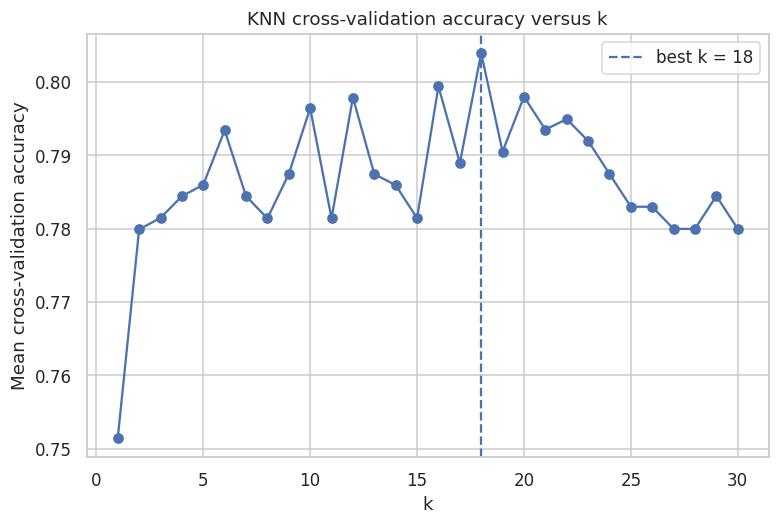

(a) Extreme k values:
training accuracy at k=1                : 0.9760
training accuracy at k=len(X_train)=668 : 0.6168
test accuracy at k=len(X_train)         : 0.6143

(b) Searching more k values:
k=1..30  : honest k=18, honest test=0.8206, peeked k=25, peeked test=0.8520, optimism=+0.0314
k=1..200 : honest k=18, honest test=0.8206, peeked k=25, peeked test=0.8520, optimism=+0.0314

(c) Effect of test-set size:
test_size  train_n  test_n  best_k honest_test_accuracy train_survival_rate test_survival_rate
     0.10      801      90      18               0.8333              0.3833             0.3889
     0.25      668     223      18               0.8206              0.3832             0.3857
     0.40      534     357       8               0.8095              0.3839             0.3838


In [ ]:
# =========================================================
# Question 5 — k, and the one-use rule
# =========================================================

# ---------------------------------------------------------
# (a) Plot CV accuracy against k
# ---------------------------------------------------------

k_values_30 = np.arange(1, 31)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    k_values_30,
    _sel["cv_scores"],
    marker="o"
)

ax.axvline(
    _sel["best_k_cv"],
    linestyle="--",
    label=f"best k = {_sel['best_k_cv']}"
)

ax.set_xlabel("k")
ax.set_ylabel("Mean cross-validation accuracy")
ax.set_title("KNN cross-validation accuracy versus k")
ax.legend()

plt.show()


# Training accuracy at the two conceptual extremes
model_k1 = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=1)
)

model_k1.fit(_Xk_tr, _yk_tr)

train_acc_k1 = model_k1.score(
    _Xk_tr,
    _yk_tr
)

model_k_all = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=len(_Xk_tr))
)

model_k_all.fit(_Xk_tr, _yk_tr)

train_acc_k_all = model_k_all.score(
    _Xk_tr,
    _yk_tr
)

test_acc_k_all = model_k_all.score(
    _Xk_te,
    _yk_te
)

print("(a) Extreme k values:")
print(f"training accuracy at k=1                : {train_acc_k1:.4f}")
print(
    f"training accuracy at k=len(X_train)={len(_Xk_tr)} : "
    f"{train_acc_k_all:.4f}"
)
print(
    f"test accuracy at k=len(X_train)         : "
    f"{test_acc_k_all:.4f}"
)


# ---------------------------------------------------------
# (b) Compare search over k=1..30 with k=1..200
# ---------------------------------------------------------

_sel_200 = honest_k_selection(
    _Xk_tr,
    _yk_tr,
    _Xk_te,
    _yk_te,
    range(1, 201),
    _k_cv
)

print("\n(b) Searching more k values:")

print(
    f"k=1..30  : honest k={_sel['best_k_cv']}, "
    f"honest test={_sel['test_accuracy']:.4f}, "
    f"peeked k={_sel['best_k_peeking']}, "
    f"peeked test={_sel['peeking_accuracy']:.4f}, "
    f"optimism={_sel['peeking_accuracy'] - _sel['test_accuracy']:+.4f}"
)

print(
    f"k=1..200 : honest k={_sel_200['best_k_cv']}, "
    f"honest test={_sel_200['test_accuracy']:.4f}, "
    f"peeked k={_sel_200['best_k_peeking']}, "
    f"peeked test={_sel_200['peeking_accuracy']:.4f}, "
    f"optimism={_sel_200['peeking_accuracy'] - _sel_200['test_accuracy']:+.4f}"
)


# ---------------------------------------------------------
# (c) Vary test_size with the same seed
# ---------------------------------------------------------

test_size_rows = []

for test_size in [0.10, 0.25, 0.40]:

    X_tr, X_te, y_tr, y_te = train_test_split(
        _X_knn,
        _y_knn,
        test_size=test_size,
        random_state=SEED,
        stratify=_y_knn
    )

    cv = StratifiedKFold(
        5,
        shuffle=True,
        random_state=SEED
    )

    result = honest_k_selection(
        X_tr,
        y_tr,
        X_te,
        y_te,
        range(1, 31),
        cv
    )

    test_size_rows.append({
        "test_size": test_size,
        "train_n": len(X_tr),
        "test_n": len(X_te),
        "best_k": result["best_k_cv"],
        "honest_test_accuracy": result["test_accuracy"],
        "train_survival_rate": y_tr.mean(),
        "test_survival_rate": y_te.mean(),
    })

test_size_results = pd.DataFrame(test_size_rows)

print("\n(c) Effect of test-set size:")
print(
    test_size_results.to_string(
        index=False,
        formatters={
            "test_size": lambda x: f"{x:.2f}",
            "honest_test_accuracy": lambda x: f"{x:.4f}",
            "train_survival_rate": lambda x: f"{x:.4f}",
            "test_survival_rate": lambda x: f"{x:.4f}",
        }
    )
)

**(a)** The small-k end is the overfitting direction, while the very large-k end is the underfitting direction.

At `k = 1`, KNN makes each prediction using only the nearest training observation. This gives a very flexible decision boundary and makes the model highly sensitive to individual training examples. In this dataset the training accuracy at `k = 1` is `0.9760`, which is very high, while the cross-validation accuracy is only about `0.751`. The training accuracy is not exactly 1 because some Titanic passengers have identical or effectively tied feature vectors with different survival outcomes, so even a 1-neighbour rule cannot classify every training row perfectly.

At the opposite extreme, `k = len(X_train) = 668`, every prediction uses the entire training set. The model therefore loses almost all local structure and behaves approximately like a majority-class classifier. Its training accuracy falls to `0.6168` and its test accuracy is `0.6143`, close to the Titanic majority-class baseline. This is strong underfitting.

The cross-validation curve reaches its highest value at `k = 18`, so the useful region is between the two extremes: small enough to preserve local structure, but large enough to smooth out noise.

**(b)** Cross-validation selected `k = 18`, which produced an honest test accuracy of `0.8206`. If I instead evaluated every candidate directly on the test set and selected the best-looking one, I would choose `k = 25` and report `0.8520`. The apparent gain is `0.0314`, or 3.14 percentage points.

The peeking value is biased upward because each test accuracy is a noisy estimate of the model's true generalisation accuracy. When I take the maximum over many noisy measurements, I preferentially select a candidate whose test score contains a favourable random error. The selected maximum therefore tends to overestimate the true performance even if every individual test score is itself an unbiased estimate before selection.

I then expanded the search from `k = 1..30` to `k = 1..200`. In this particular run, the result did not change: cross-validation still selected `k = 18` with honest test accuracy `0.8206`, while test-set peeking still selected `k = 25` with `0.8520`, so the observed optimism remained `+0.0314`.

This does not contradict the multiple-comparisons argument. Expanding the candidate set cannot reduce the maximum test score over the original candidates, but it does not have to increase it either. Here, none of the additional values from 31 to 200 happened to beat the already observed test score at `k = 25`. In expectation, searching more alternatives gives more opportunities to exploit test-set noise, which is why the test set should not be used for hyperparameter selection.

**(c)** Changing the test-set size produced:

| test size | training rows | test rows | selected k | honest test accuracy |
|---:|---:|---:|---:|---:|
| 0.10 | 801 | 90 | 18 | 0.8333 |
| 0.25 | 668 | 223 | 18 | 0.8206 |
| 0.40 | 534 | 357 | 8 | 0.8095 |

There is a trade-off. A smaller test set leaves more observations available for training, so the fitted model and the cross-validation procedure have more data available to learn from. However, the final test accuracy is then based on fewer observations and is therefore a noisier estimate of generalisation performance.

A larger test set gives a more statistically stable final evaluation because it averages performance over more unseen observations, but it leaves fewer observations for model fitting and hyperparameter selection. In this experiment the honest test accuracy decreased from `0.8333` with a 10% test split to `0.8095` with a 40% test split, while the selected `k` changed from 18 to 8.

Using `stratify=y` protects the split from accidental changes in class balance. The overall Titanic survival proportion is about 38%, and the observed training and test proportions remained very similar: for example, with the 10% split they were `0.3833` and `0.3889`, and with the 40% split they were `0.3839` and `0.3838`. Without stratification, a random split could place disproportionately many survivors or non-survivors into one subset, causing differences in measured accuracy that reflect the split rather than the model.

## 9. Task 8 — Recover an SVM boundary in original units

Applied. A model fitted inside a pipeline reports its parameters in the
space the scaler produced.

*see Practice 3 §11.4*

In [ ]:
def boundary_in_original_units(pipeline):
    """Convert a fitted (StandardScaler -> linear SVC) pipeline's decision
    boundary from scaled space back to original coordinates.

    The pipeline has exactly two steps: 'standardscaler' and 'svc', and
    the SVC has kernel='linear' and was fitted on two features.

    In scaled space the boundary is  w1*z1 + w2*z2 + b = 0, with
    z1 = (x - mu_x)/s_x and z2 = (y - mu_y)/s_y.

    Solve for y and return a tuple (slope, intercept) such that
    y = slope * x + intercept is that same boundary in original units.

    Raise ValueError if w2 is zero (a vertical boundary has no such form).
    """

    scaler = pipeline.named_steps["standardscaler"]
    svc = pipeline.named_steps["svc"]

    w1, w2 = svc.coef_[0]
    b = svc.intercept_[0]

    mu_x, mu_y = scaler.mean_
    s_x, s_y = scaler.scale_

    if np.isclose(w2, 0.0):
        raise ValueError(
            "The decision boundary is vertical and cannot be written as y = slope*x + intercept."
        )

    slope = -(w1 * s_y) / (w2 * s_x)

    intercept = (
        mu_y
        - slope * mu_x
        - (b * s_y) / w2
    )

    return float(slope), float(intercept)

In [ ]:
_svr_rng = np.random.default_rng(SEED)
_n = 300
_x_lines = _svr_rng.uniform(0, 5, _n)
_y1 = 1.0 * _x_lines + 3.0 + _svr_rng.normal(0, 1, _n)
_y2 = 2.0 * _x_lines + 5.0 + _svr_rng.normal(0, 1, _n)

_X_two = np.vstack([np.column_stack([_x_lines, _y1]), np.column_stack([_x_lines, _y2])])
_y_two = np.hstack([np.zeros(_n, dtype=int), np.ones(_n, dtype=int)])

_pipe = make_pipeline(StandardScaler(), SVC(kernel="linear", C=1.0, random_state=SEED))
_pipe.fit(_X_two, _y_two)

_slope, _intercept = boundary_in_original_units(_pipe)

# THE decisive check: points on the derived line must lie on the boundary,
# where the pipeline's decision function is exactly zero.
_check_x = np.linspace(0.5, 4.5, 9)
_check_y = _slope * _check_x + _intercept
_decisions = _pipe.decision_function(np.column_stack([_check_x, _check_y]))
assert np.allclose(_decisions, 0.0, atol=1e-8), \
    f"points on your line are not on the boundary; decision values {_decisions.round(6)}"

# The boundary must lie between the two generating lines.
assert 1.0 < _slope < 2.0, f"slope {_slope:.4f} should be between the true slopes 1 and 2"

# Points clearly above and below must fall on opposite sides.
assert _pipe.predict([[2.5, _slope * 2.5 + _intercept + 4]])[0] == 1
assert _pipe.predict([[2.5, _slope * 2.5 + _intercept - 4]])[0] == 0

print(f"boundary in original units: y = {_slope:.4f} * x + {_intercept:.4f}")
print(f"decision function on the line: {np.abs(_decisions).max():.2e} (essentially zero)")
print("Task 8 passed.")

boundary in original units: y = 1.4168 * x + 4.1898
decision function on the line: 1.40e-14 (essentially zero)
Task 8 passed.


### Question 6 — C, gamma and the kernel

**(a)** Refit the two-line classifier with `C` = 0.001, 1, 1000. Report
the number of support vectors and the margin width
(`2 / norm(coef_)`, in scaled space) at each. **Which direction is
underfitting and which is overfitting?** What does `C` do to the margin
at each extreme?

**(b)** Now switch to `kernel='rbf'` and sweep `gamma` over 0.01, 1, 100
at fixed `C=1`, scoring by cross-validation. Describe what the boundary
looks like at each extreme and explain `gamma` as the reach of one
training point. Which extreme memorises?

**(c)** These data are linearly separable apart from noise. Does the RBF
kernel beat the linear one here? Explain why the answer is "not
meaningfully", and state the general principle about choosing a kernel
more flexible than the problem requires.

(a) Linear SVM — effect of C
C=0.001    support_vectors=600  margin_width=4.9368  train_accuracy=0.8350  CV_accuracy=0.8317
C=1        support_vectors= 74  margin_width=0.4146  train_accuracy=0.9717  CV_accuracy=0.9717
C=1000     support_vectors= 46  margin_width=0.2189  train_accuracy=0.9733  CV_accuracy=0.9717

(b) RBF SVM — effect of gamma
gamma train_accuracy cv_accuracy  support_vectors
 0.01         0.9600      0.9650              284
    1         0.9733      0.9683               86
  100         0.9850      0.9550              487


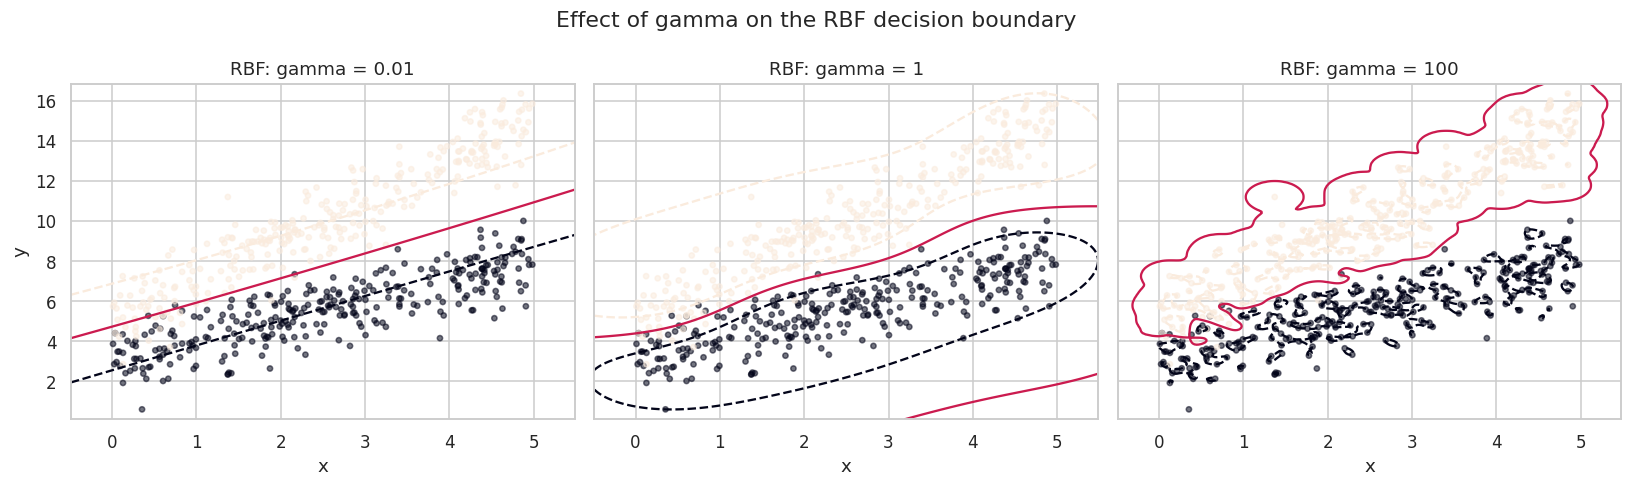


(c) Linear versus RBF:
linear SVM, C=1: CV accuracy = 0.9717
best tested RBF: gamma=1, CV accuracy=0.9683
difference RBF - linear = -0.0033


In [ ]:
# =========================================================
# Question 6 — C, gamma and the kernel
# =========================================================

svm_cv = StratifiedKFold(
    5,
    shuffle=True,
    random_state=SEED
)

# ---------------------------------------------------------
# (a) Linear SVM: effect of C
# ---------------------------------------------------------

print("(a) Linear SVM — effect of C")

for C_value in [0.001, 1, 1000]:
    model = make_pipeline(
        StandardScaler(),
        SVC(
            kernel="linear",
            C=C_value,
            random_state=SEED
        )
    )

    model.fit(_X_two, _y_two)

    svc = model.named_steps["svc"]

    n_support = int(svc.n_support_.sum())
    margin_width = 2 / np.linalg.norm(svc.coef_[0])

    cv_scores = cross_val_score(
        model,
        _X_two,
        _y_two,
        cv=svm_cv,
        scoring="accuracy"
    )

    print(
        f"C={C_value:<8g} "
        f"support_vectors={n_support:3d}  "
        f"margin_width={margin_width:.4f}  "
        f"train_accuracy={model.score(_X_two, _y_two):.4f}  "
        f"CV_accuracy={cv_scores.mean():.4f}"
    )


# ---------------------------------------------------------
# (b) RBF SVM: effect of gamma
# ---------------------------------------------------------

gamma_values = [0.01, 1, 100]

rbf_rows = []

print("\n(b) RBF SVM — effect of gamma")

for gamma_value in gamma_values:
    model = make_pipeline(
        StandardScaler(),
        SVC(
            kernel="rbf",
            C=1,
            gamma=gamma_value,
            random_state=SEED
        )
    )

    model.fit(_X_two, _y_two)

    cv_scores = cross_val_score(
        model,
        _X_two,
        _y_two,
        cv=svm_cv,
        scoring="accuracy"
    )

    train_accuracy = model.score(
        _X_two,
        _y_two
    )

    rbf_rows.append({
        "gamma": gamma_value,
        "train_accuracy": train_accuracy,
        "cv_accuracy": cv_scores.mean(),
        "support_vectors":
            int(model.named_steps["svc"].n_support_.sum())
    })

rbf_results = pd.DataFrame(rbf_rows)

print(rbf_results.to_string(
    index=False,
    formatters={
        "gamma": lambda x: f"{x:g}",
        "train_accuracy": lambda x: f"{x:.4f}",
        "cv_accuracy": lambda x: f"{x:.4f}",
    }
))


# ---------------------------------------------------------
# Plot the RBF decision boundaries
# ---------------------------------------------------------

x_min = _X_two[:, 0].min() - 0.5
x_max = _X_two[:, 0].max() + 0.5
y_min = _X_two[:, 1].min() - 0.5
y_max = _X_two[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 250),
    np.linspace(y_min, y_max, 250)
)

grid = np.column_stack([
    xx.ravel(),
    yy.ravel()
])

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4.5),
    sharex=True,
    sharey=True
)

for ax, gamma_value in zip(axes, gamma_values):
    model = make_pipeline(
        StandardScaler(),
        SVC(
            kernel="rbf",
            C=1,
            gamma=gamma_value,
            random_state=SEED
        )
    )

    model.fit(_X_two, _y_two)

    decision = model.decision_function(grid).reshape(xx.shape)

    ax.contour(
        xx,
        yy,
        decision,
        levels=[-1, 0, 1],
        linestyles=["--", "-", "--"]
    )

    ax.scatter(
        _X_two[:, 0],
        _X_two[:, 1],
        c=_y_two,
        s=12,
        alpha=0.55
    )

    ax.set_title(f"RBF: gamma = {gamma_value}")
    ax.set_xlabel("x")

axes[0].set_ylabel("y")

fig.suptitle("Effect of gamma on the RBF decision boundary")
fig.tight_layout()

plt.show()


# ---------------------------------------------------------
# (c) Linear versus RBF
# ---------------------------------------------------------

linear_model = make_pipeline(
    StandardScaler(),
    SVC(
        kernel="linear",
        C=1,
        random_state=SEED
    )
)

linear_cv = cross_val_score(
    linear_model,
    _X_two,
    _y_two,
    cv=svm_cv,
    scoring="accuracy"
).mean()

best_rbf_row = rbf_results.loc[
    rbf_results["cv_accuracy"].idxmax()
]

print("\n(c) Linear versus RBF:")
print(f"linear SVM, C=1: CV accuracy = {linear_cv:.4f}")
print(
    f"best tested RBF: gamma={best_rbf_row['gamma']:g}, "
    f"CV accuracy={best_rbf_row['cv_accuracy']:.4f}"
)
print(
    f"difference RBF - linear = "
    f"{best_rbf_row['cv_accuracy'] - linear_cv:+.4f}"
)

**(a)** The effect of `C` is visible in both the margin width and the number of support vectors.

At `C = 0.001`, the model uses all `600` observations as support vectors and has a very wide margin of `4.9368`. Its training accuracy is only `0.8350` and its cross-validated accuracy is `0.8317`. This is the underfitting direction: violations are cheap, so the classifier accepts many points inside the margin or on the wrong side in order to maintain a very wide and strongly regularised boundary.

At `C = 1`, the margin shrinks to `0.4146`, only `74` points are support vectors, and both training and CV accuracy rise to `0.9717`.

At `C = 1000`, the margin becomes even narrower, `0.2189`, and the number of support vectors falls to `46`. Training accuracy increases slightly to `0.9733`, while CV accuracy remains `0.9717`. Thus, increasing `C` moves toward the overfitting direction: mistakes and margin violations become increasingly expensive, so the model sacrifices margin width to fit the training observations more closely. In this dataset, however, the CV score does not deteriorate at `C = 1000`, so the large value represents increased model sensitivity without measurable overfitting in the observed CV accuracy.

**(b)** With an RBF kernel and `C = 1`, the three tested `gamma` values produced different levels of boundary complexity.

At `gamma = 0.01`, training accuracy is `0.9600` and CV accuracy is `0.9650`, with `284` support vectors. The decision boundary is very smooth and almost linear. A small `gamma` gives each training point a long spatial reach, so many observations contribute to broad, smooth changes in the decision function. This is the underfitting direction when the true boundary requires more local structure.

At `gamma = 1`, training accuracy is `0.9733` and CV accuracy reaches the best RBF result, `0.9683`, with `86` support vectors. The boundary is somewhat more flexible while still remaining smooth enough to generalise well.

At `gamma = 100`, training accuracy rises to `0.9850`, but CV accuracy falls to `0.9550`, and the classifier uses `487` support vectors. The plotted boundary becomes highly irregular, with many small local bends and islands around individual observations. Large `gamma` means that the influence of each point decays very quickly with distance, so each observation affects only a very small neighbourhood. This is the memorising or overfitting extreme.

Therefore, `gamma` can be interpreted as controlling the reach of an individual training point: small `gamma` gives long reach and a smooth global boundary, while large `gamma` gives short reach and a highly local boundary.

**(c)** The RBF kernel does not meaningfully outperform the linear kernel on these data. The linear SVM with `C = 1` achieved a cross-validated accuracy of `0.9717`, while the best tested RBF configuration, `gamma = 1`, achieved `0.9683`. The difference is `-0.0033` in favour of the linear model.

This is consistent with the structure of the data. The two classes were generated around two approximately linear trends, so a straight separating boundary already matches the underlying problem well. The RBF kernel has substantially more flexibility, but that flexibility does not add useful signal here; at large `gamma` it instead begins to fit local noise.

The general principle is to avoid using a more flexible kernel merely because it can represent more complicated boundaries. If a simpler model already matches the structure of the problem and performs as well or better under cross-validation, the additional flexibility mainly increases variance, computational cost and the opportunity to overfit.

## 10. Task 9 — Choosing the number of clusters

Applied.

*see Practice 3 §13.3 and §14.5*

In [ ]:
def cluster_selection(X, k_values):
    """Score k-means and a Gaussian mixture across several k.

    For each k in `k_values` (all >= 2), compute four numbers:
        'inertia'      KMeans(n_clusters=k, n_init=10, random_state=SEED).inertia_
        'silhouette'   silhouette_score of that KMeans labelling
        'bic'          GaussianMixture(n_components=k, covariance_type='full',
                       random_state=SEED).bic(X)
        'aic'          the same model's aic(X)

    Return a DataFrame indexed by k with those four columns, in that order.
    """

    rows = []

    for k in k_values:
        # -------------------------
        # KMeans
        # -------------------------
        kmeans = KMeans(
            n_clusters=k,
            n_init=10,
            random_state=SEED
        )

        labels = kmeans.fit_predict(X)

        inertia = float(kmeans.inertia_)

        silhouette = float(
            silhouette_score(X, labels)
        )

        # -------------------------
        # Gaussian Mixture
        # -------------------------
        gmm = GaussianMixture(
            n_components=k,
            covariance_type="full",
            random_state=SEED
        )

        gmm.fit(X)

        bic = float(gmm.bic(X))
        aic = float(gmm.aic(X))

        rows.append({
            "k": k,
            "inertia": inertia,
            "silhouette": silhouette,
            "bic": bic,
            "aic": aic,
        })

    result = pd.DataFrame(rows).set_index("k")

    return result[
        ["inertia", "silhouette", "bic", "aic"]
    ]

In [ ]:
_blob_rng = np.random.default_rng(SEED)
_centres = np.array([[-4.0, -2.0], [0.0, 3.5], [4.0, -1.0], [6.5, 4.0]])
_X_blobs = np.vstack([_blob_rng.multivariate_normal(c, np.eye(2), 75) for c in _centres])

_scores = cluster_selection(_X_blobs, range(2, 8))

assert list(_scores.columns) == ["inertia", "silhouette", "bic", "aic"]
assert len(_scores) == 6

# Inertia falls monotonically: more clusters always fit the points more tightly.
assert np.all(np.diff(_scores["inertia"].values) < 0), \
    "inertia must decrease as k increases, which is why it cannot be minimised to choose k"

# On four well-separated round blobs, every criterion should find four.
assert _scores["silhouette"].idxmax() == 4, \
    f"silhouette chose {_scores['silhouette'].idxmax()}, expected 4 on four round blobs"
assert _scores["bic"].idxmin() == 4, f"BIC chose {_scores['bic'].idxmin()}, expected 4"

print(_scores.round(3).to_string())
print(f"\nsilhouette -> {_scores['silhouette'].idxmax()},  "
      f"BIC -> {_scores['bic'].idxmin()},  AIC -> {_scores['aic'].idxmin()}")
print("Task 9 passed.")

     inertia  silhouette        bic        aic
k                                             
2 3,260.9450      0.4940 2,842.1730 2,801.4310
3 1,694.5460      0.5650 2,716.3210 2,653.3560
4   553.3610      0.6970 2,603.9330 2,518.7460
5   495.1520      0.5980 2,631.5810 2,524.1720
6   443.6920      0.5070 2,664.4790 2,534.8470
7   387.6340      0.4260 2,691.7670 2,539.9120

silhouette -> 4,  BIC -> 4,  AIC -> 4
Task 9 passed.


### Question 7 — clustering choices

**(a)** Plot inertia against k. Explain why it cannot be minimised to
choose k, and what the "elbow" is supposed to represent. Then state
honestly how confident you are reading the elbow on your own plot.

**(b)** Now build the harder data below — three tilted components, two of
which overlap — and run `cluster_selection` on it. **Silhouette and BIC
will disagree.** Report both answers, say which is right, and explain
*why* the silhouette gives the answer it does in terms of what it
measures.

**(c)** Re-run k-means on that data with `n_init=1` and ten different
`random_state` values, recording the inertia each time. Report the spread.
What is `n_init` for, and what does `init='k-means++'` change?

**(d)** Fit a GMM to that data with each `covariance_type` in
`('full', 'tied', 'diag', 'spherical')` and report the adjusted Rand
index against the true labels. Which assumption is each making, and which
one reproduces k-means' behaviour?

In [ ]:
# The harder data for parts (b), (c) and (d). Do not modify this cell.
_hard_rng = np.random.default_rng(SEED)
X_hard = np.vstack([
    _hard_rng.multivariate_normal([0.0, 0.0], [[2.0, 2.0], [2.0, 5.0]], 300),
    _hard_rng.multivariate_normal([4.0, 4.0], [[7.0, -2.0], [-2.0, 3.0]], 300),
    _hard_rng.multivariate_normal([6.0, 6.5], [[3.0, 1.5], [1.5, 2.0]], 300),
])
y_hard = np.repeat([0, 1, 2], 300)

print("X_hard", X_hard.shape, " true components: 3")

X_hard (900, 2)  true components: 3


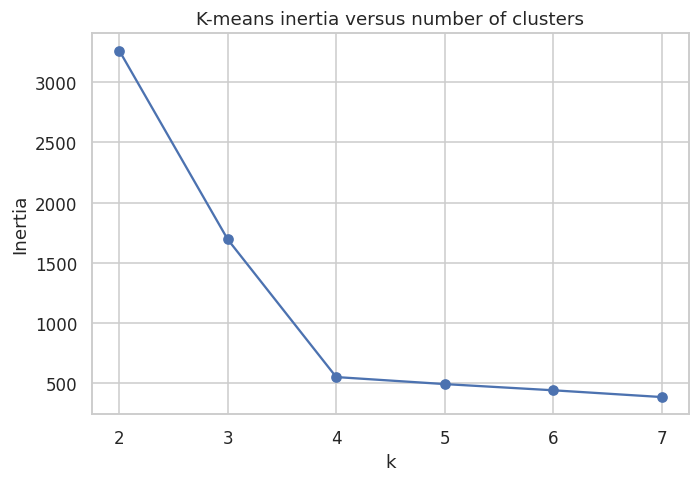

(a) Original four-blob data:
     inertia  silhouette
k                       
2 3,260.9450      0.4940
3 1,694.5460      0.5650
4   553.3610      0.6970
5   495.1520      0.5980
6   443.6920      0.5070
7   387.6340      0.4260

(b) Hard data:
     inertia  silhouette        bic        aic
k                                             
2 7,175.0020      0.5160 8,512.4190 8,459.5920
3 4,690.2510      0.4230 8,410.6690 8,329.0280
4 3,470.1580      0.4280 8,451.9990 8,341.5440
5 2,822.5210      0.4040 8,490.5460 8,351.2760
6 2,355.3400      0.3660 8,526.4190 8,358.3360
7 1,994.2770      0.3680 8,559.2670 8,362.3680

silhouette chooses: 2
BIC chooses       : 3
AIC chooses       : 3
true components   : 3


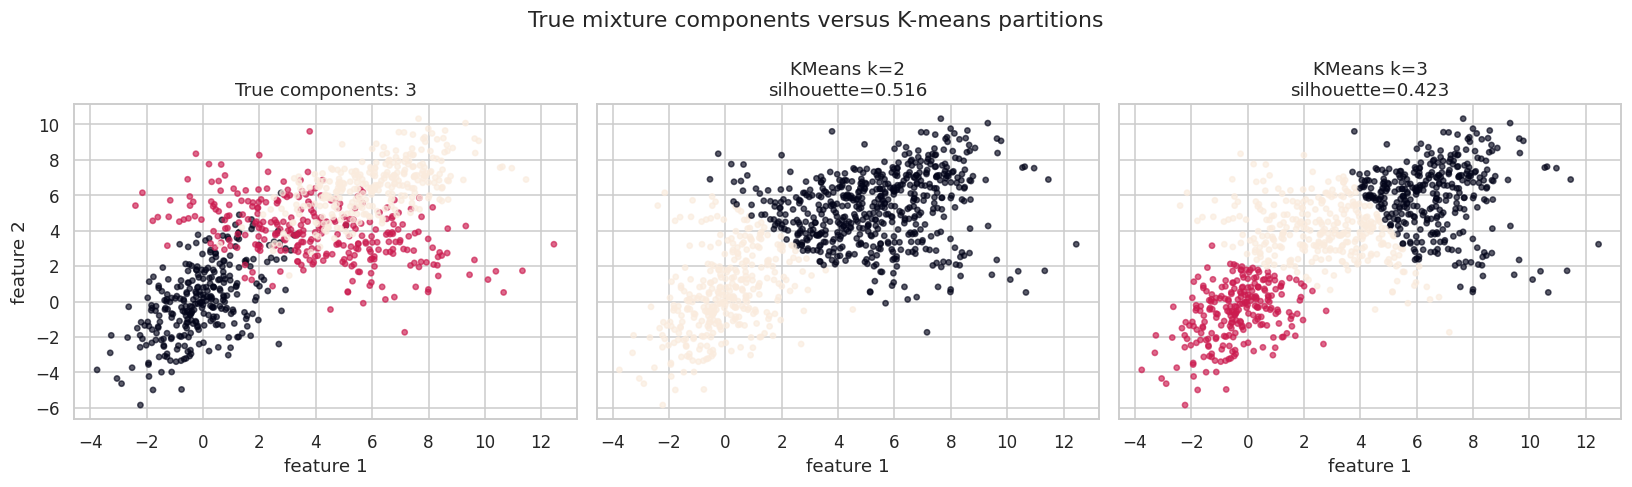


(c) KMeans with n_init=1 over ten seeds:
[4691.929 4690.251 4690.251 4691.929 4691.929 4691.929 4691.929 4692.743
 4691.929 4690.251]
best inertia   : 4690.251
worst inertia  : 4692.743
spread         : 2.493

(d) GMM covariance types:
                   ARI        BIC        AIC
covariance_type                             
full            0.6407 8,410.6689 8,329.0282
tied            0.4493 8,561.6693 8,508.8430
diag            0.4362 8,544.7385 8,477.5050
spherical       0.4527 8,576.1309 8,523.3046

KMeans k=3 ARI for comparison: 0.4606


In [ ]:
# =========================================================
# Question 7 — clustering choices
# =========================================================


# ---------------------------------------------------------
# (a) Inertia and the elbow on the original four-blob data
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(
    _scores.index,
    _scores["inertia"],
    marker="o"
)

ax.set_xlabel("k")
ax.set_ylabel("Inertia")
ax.set_title("K-means inertia versus number of clusters")

plt.show()

print("(a) Original four-blob data:")
print(
    _scores[["inertia", "silhouette"]]
    .round(3)
    .to_string()
)


# ---------------------------------------------------------
# (b) Hard data: silhouette versus BIC
# ---------------------------------------------------------

hard_scores = cluster_selection(
    X_hard,
    range(2, 8)
)

print("\n(b) Hard data:")
print(
    hard_scores
    .round(3)
    .to_string()
)

best_silhouette = int(
    hard_scores["silhouette"].idxmax()
)

best_bic = int(
    hard_scores["bic"].idxmin()
)

best_aic = int(
    hard_scores["aic"].idxmin()
)

print(
    f"\nsilhouette chooses: {best_silhouette}"
)
print(
    f"BIC chooses       : {best_bic}"
)
print(
    f"AIC chooses       : {best_aic}"
)
print(
    "true components   : 3"
)


# Visualise the true components and the two competing KMeans choices
fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4.5),
    sharex=True,
    sharey=True
)

axes[0].scatter(
    X_hard[:, 0],
    X_hard[:, 1],
    c=y_hard,
    s=12,
    alpha=0.65
)
axes[0].set_title("True components: 3")

for ax, k in zip(axes[1:], [2, 3]):
    km = KMeans(
        n_clusters=k,
        n_init=10,
        random_state=SEED
    )

    labels = km.fit_predict(X_hard)

    ax.scatter(
        X_hard[:, 0],
        X_hard[:, 1],
        c=labels,
        s=12,
        alpha=0.65
    )

    ax.set_title(
        f"KMeans k={k}\n"
        f"silhouette="
        f"{silhouette_score(X_hard, labels):.3f}"
    )

for ax in axes:
    ax.set_xlabel("feature 1")

axes[0].set_ylabel("feature 2")

fig.suptitle(
    "True mixture components versus K-means partitions"
)

fig.tight_layout()
plt.show()


# ---------------------------------------------------------
# (c) KMeans sensitivity to initialisation
# ---------------------------------------------------------

single_start_inertias = []

for seed in range(10):
    km = KMeans(
        n_clusters=3,
        n_init=1,
        random_state=seed
    )

    km.fit(X_hard)

    single_start_inertias.append(
        km.inertia_
    )

single_start_inertias = np.asarray(
    single_start_inertias
)

print("\n(c) KMeans with n_init=1 over ten seeds:")
print(
    np.round(single_start_inertias, 3)
)

print(
    f"best inertia   : "
    f"{single_start_inertias.min():.3f}"
)

print(
    f"worst inertia  : "
    f"{single_start_inertias.max():.3f}"
)

print(
    f"spread         : "
    f"{single_start_inertias.max() - single_start_inertias.min():.3f}"
)


# ---------------------------------------------------------
# (d) GMM covariance assumptions
# ---------------------------------------------------------

covariance_rows = []

for covariance_type in [
    "full",
    "tied",
    "diag",
    "spherical",
]:
    gmm = GaussianMixture(
        n_components=3,
        covariance_type=covariance_type,
        random_state=SEED
    )

    labels = gmm.fit_predict(X_hard)

    ari = adjusted_rand_score(
        y_hard,
        labels
    )

    covariance_rows.append({
        "covariance_type": covariance_type,
        "ARI": ari,
        "BIC": gmm.bic(X_hard),
        "AIC": gmm.aic(X_hard),
    })

covariance_results = pd.DataFrame(
    covariance_rows
).set_index("covariance_type")

print("\n(d) GMM covariance types:")
print(
    covariance_results
    .round(4)
    .to_string()
)


# KMeans ARI for comparison
kmeans_3 = KMeans(
    n_clusters=3,
    n_init=10,
    random_state=SEED
)

kmeans_labels = kmeans_3.fit_predict(
    X_hard
)

kmeans_ari = adjusted_rand_score(
    y_hard,
    kmeans_labels
)

print(
    f"\nKMeans k=3 ARI for comparison: "
    f"{kmeans_ari:.4f}"
)

**(a)** Inertia decreases monotonically as the number of K-means clusters increases: it falls from `3260.945` at `k = 2` to `1694.546` at `k = 3`, then to `553.361` at `k = 4`, and continues decreasing to `387.634` at `k = 7`.

Therefore, inertia cannot simply be minimised to choose `k`. Adding more clusters can never make the within-cluster sum of squared distances worse; in the limiting case where every point forms its own cluster, inertia approaches zero.

The elbow is intended to identify the point after which adding another cluster gives only a relatively small improvement in inertia. On this dataset the elbow at `k = 4` is fairly clear: the reduction from `k = 3` to `k = 4` is about `1141.185`, whereas the reduction from `k = 4` to `k = 5` is only about `58.209`. I would therefore be reasonably confident reading `k = 4` from this particular elbow plot. However, the elbow method is visual and subjective; on a smoother curve the choice could be much less clear. Here it is also supported independently by the silhouette, BIC and AIC criteria, all of which select four clusters.

**(b)** On the harder dataset, the silhouette and BIC disagree. The silhouette reaches its maximum at `k = 2`, with a score of `0.5160`, whereas BIC is minimised at `k = 3`, with `BIC = 8410.6690`. AIC also selects `k = 3`, with `AIC = 8329.0280`. Because these data were generated from exactly three Gaussian components, `k = 3` is the correct answer in this controlled experiment.

The silhouette is not malfunctioning. It measures how much closer each point is to its own assigned cluster than to the nearest competing cluster, so it prefers compact and well-separated groups. Two of the true Gaussian components overlap substantially. Merging those overlapping components into one larger group produces a cleaner geometric separation from the remaining component, which raises the silhouette from `0.4230` at `k = 3` to `0.5160` at `k = 2`.

BIC asks a different question. A Gaussian mixture is a probabilistic model, so BIC evaluates how well the mixture explains the observed probability distribution while penalising the extra parameters required by additional components. Because the data really were generated by three differently shaped Gaussian components, the three-component full-covariance mixture gives the better model despite the overlap. Therefore, for this GMM problem BIC is the more appropriate criterion.

**(c)** With K-means fixed at `k = 3`, `n_init = 1`, and ten different random seeds, the inertias ranged from `4690.251` to `4692.743`. The spread was therefore only `2.493`. Most runs converged near either `4690.251` or `4691.929`, so initialisation has a measurable but small effect on this particular dataset.

K-means optimises a non-convex objective and can converge to different local minima depending on its initial cluster centres. `n_init` controls how many independent initialisations are tried. With a value greater than one, K-means fits the model repeatedly and retains the solution with the lowest inertia, reducing the chance of keeping a poor local optimum.

`init='k-means++'` improves the starting positions themselves. Instead of choosing all initial centres uniformly at random, it chooses centres so that they tend to be spread apart, with points far from existing centres having a greater probability of being selected next. This usually produces better starting configurations and makes poor local minima less likely. Thus, `k-means++` improves each start, while `n_init` provides additional protection by trying multiple starts.

**(d)** The adjusted Rand index results for three-component Gaussian mixtures were:

| covariance type | ARI |
|---|---:|
| `full` | `0.6407` |
| `tied` | `0.4493` |
| `diag` | `0.4362` |
| `spherical` | `0.4527` |

For comparison, K-means with `k = 3` achieved an ARI of `0.4606`.

The `full` covariance model allows every component to have its own complete covariance matrix. It can therefore represent a different size, elongation and orientation for every Gaussian cluster. This matches the way the synthetic data were generated, and it gives the highest ARI, `0.6407`.

The `tied` model allows a full covariance matrix but forces all components to share that same matrix. It can represent tilted ellipses, but it cannot give the three clusters different covariance shapes.

The `diag` model gives each component its own variances along the coordinate axes but forces all off-diagonal covariances to zero. Its clusters can have different axis-aligned elliptical shapes, but they cannot rotate to match the tilted components in these data.

The `spherical` model assumes isotropic clusters: within each component all feature directions have the same variance. This is the covariance assumption closest to K-means, whose Euclidean-distance objective naturally favours spherical clusters. Its ARI of `0.4527` is correspondingly close to the K-means ARI of `0.4606`. It is not exactly equivalent to K-means because a spherical GMM is still a probabilistic mixture with soft likelihood-based assignments and can estimate component-specific variances.

The comparison shows why the full-covariance GMM performs substantially better here: the real groups are tilted and have different covariance structures, which K-means and the more restrictive GMM covariance types cannot represent adequately.

## 11. Task 10 — Open-ended: an end-to-end regression study

No assert. Marked on the written analysis and on the discipline of the
procedure.

**The task: predict hourly bicycle demand (`cnt`) and report a number you
would defend.**

`bike_sharing_hourly.csv` is documented in `practice/datasets/README.md`.
Work through the following, in this order, and write up what you find.

1. **Feature preparation.** Decide what to do with each column. `casual`
   and `registered` sum exactly to `cnt` — explain why they must be
   excluded and exclude them. Encode the integer-coded categories
   properly (Practice 3 §10.2) and justify each choice in one line.

2. **Split once.** Hold out a test set and do not look at it again until
   step 6. State your `test_size` and why.

3. **A baseline.** Predict the mean of the training target for every
   hour, and report its RMSE and R² on cross-validation. Every later
   number is read against this.

4. **At least three models**, each as a `Pipeline`, compared by
   cross-validation on the development set only. Report mean and standard
   deviation across folds, not a single number. Use at least one linear
   and one non-linear model.

5. **Tune the best one** with `GridSearchCV` over the pipeline. State the
   grid and how many fits it implies.

6. **Open the test set once.** Report RMSE, MAE and R². Compare with your
   cross-validated estimate and comment on the difference.

7. **Diagnose.** Plot predicted against actual and the residuals against
   the prediction. Does the model predict impossible values? Do the
   residuals fan out? What does that say about which hours it fails on?

8. **A decision.** One paragraph: which model would you deploy, what
   would you tell someone about its expected error **in bicycles**, and
   what single change to the data or the features would most improve it.

A good answer treats step 6 as irreversible and says so. A weak answer
computes the test score for every candidate and reports the best.

In [ ]:
# =========================================================
# Task 10 — End-to-end regression study
# Predict hourly bicycle demand (cnt)
# =========================================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import ParameterGrid
from sklearn.base import clone


# =========================================================
# 1. FEATURE PREPARATION
# =========================================================

data = bikes.copy()

y = data["cnt"].astype(float)

# casual + registered == cnt exactly, therefore both are target leakage.
assert (data["casual"] + data["registered"] == data["cnt"]).all()

X = data.drop(
    columns=[
        "instant",       # record identifier
        "dteday",        # raw date; calendar information is represented below
        "casual",        # target leakage
        "registered",    # target leakage
        "cnt",           # target
    ]
)

# Nominal/cyclic categorical variables:
categorical_features = [
    "season",
    "mnth",
    "hr",
    "weekday",
    "weathersit",
]

# Already meaningful as binary 0/1 indicators:
binary_features = [
    "yr",
    "holiday",
    "workingday",
]

# Continuous measurements:
numeric_features = [
    "temp",
    "atemp",
    "hum",
    "windspeed",
]

print("1. FEATURE PREPARATION")
print("Dropped instant: row identifier.")
print("Dropped dteday: raw date; calendar structure is represented by yr/mnth/season/weekday.")
print("Dropped casual and registered: exact target leakage because casual + registered == cnt.")
print("One-hot encoded: season, mnth, hr, weekday, weathersit.")
print("Kept as binary 0/1: yr, holiday, workingday.")
print("Continuous: temp, atemp, hum, windspeed.")
print("Leakage identity confirmed:", bool(
    (data["casual"] + data["registered"] == data["cnt"]).all()
))
print("X shape:", X.shape, "| y shape:", y.shape)


preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features,
        ),
        (
            "numeric",
            StandardScaler(),
            numeric_features,
        ),
        (
            "binary",
            "passthrough",
            binary_features,
        ),
    ]
)


# =========================================================
# 2. SPLIT ONCE
# =========================================================

X_dev, X_test, y_dev, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED
)

print("\n2. SPLIT")
print("test_size = 0.20")
print("development:", X_dev.shape)
print("test       :", X_test.shape)
print("The test set is now CLOSED until step 6.")


# Cross-validation is used only on the development set.
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)


def cv_summary(model, X_data, y_data):
    rmse_scores = -cross_val_score(
        model,
        X_data,
        y_data,
        cv=cv,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    r2_scores = cross_val_score(
        model,
        X_data,
        y_data,
        cv=cv,
        scoring="r2",
        n_jobs=-1
    )

    return {
        "rmse_mean": float(rmse_scores.mean()),
        "rmse_std": float(rmse_scores.std()),
        "r2_mean": float(r2_scores.mean()),
        "r2_std": float(r2_scores.std()),
    }


# =========================================================
# 3. BASELINE
# =========================================================

baseline = DummyRegressor(strategy="mean")

baseline_result = cv_summary(
    baseline,
    X_dev,
    y_dev
)

print("\n3. BASELINE — training-fold mean")
print(
    f"CV RMSE = {baseline_result['rmse_mean']:.2f} "
    f"+/- {baseline_result['rmse_std']:.2f}"
)
print(
    f"CV R2   = {baseline_result['r2_mean']:.4f} "
    f"+/- {baseline_result['r2_std']:.4f}"
)


# =========================================================
# 4. COMPARE AT LEAST THREE MODELS
# =========================================================

candidates = {
    "LinearRegression": Pipeline([
        ("prep", clone(preprocessor)),
        ("model", LinearRegression()),
    ]),

    "KNN": Pipeline([
        ("prep", clone(preprocessor)),
        ("model", KNeighborsRegressor(
            n_neighbors=10
        )),
    ]),

    "RandomForest": Pipeline([
        ("prep", clone(preprocessor)),
        ("model", RandomForestRegressor(
            n_estimators=100,
            random_state=SEED,
            n_jobs=1
        )),
    ]),
}

comparison_rows = []

for name, model in candidates.items():
    result = cv_summary(
        model,
        X_dev,
        y_dev
    )

    comparison_rows.append({
        "model": name,
        "RMSE_mean": result["rmse_mean"],
        "RMSE_std": result["rmse_std"],
        "R2_mean": result["r2_mean"],
        "R2_std": result["r2_std"],
    })

comparison = (
    pd.DataFrame(comparison_rows)
    .set_index("model")
    .sort_values("RMSE_mean")
)

print("\n4. CANDIDATE MODELS — DEVELOPMENT SET ONLY")
print(comparison.round(4).to_string())

best_name = comparison["RMSE_mean"].idxmin()

print("\nBest candidate by CV RMSE:", best_name)
print("Test set has still NOT been used.")


# =========================================================
# 5. TUNE THE BEST MODEL
# =========================================================

# Define a grid for whichever candidate won.
tuning = {
    "LinearRegression": (
        Pipeline([
            ("prep", clone(preprocessor)),
            ("model", LinearRegression()),
        ]),
        {
            "model__fit_intercept": [True, False],
        }
    ),

    "KNN": (
        Pipeline([
            ("prep", clone(preprocessor)),
            ("model", KNeighborsRegressor()),
        ]),
        {
            "model__n_neighbors": [5, 10, 20, 30],
            "model__weights": ["uniform", "distance"],
        }
    ),

    "RandomForest": (
        Pipeline([
            ("prep", clone(preprocessor)),
            ("model", RandomForestRegressor(
                random_state=SEED,
                n_jobs=1
            )),
        ]),
        {
            "model__n_estimators": [150, 300],
            "model__max_depth": [12, 20, None],
            "model__min_samples_leaf": [1, 3],
        }
    ),
}

selected_pipeline, param_grid = tuning[best_name]

n_combinations = len(list(ParameterGrid(param_grid)))
n_folds = cv.get_n_splits()
n_cv_fits = n_combinations * n_folds

print("\n5. GRID SEARCH")
print("Selected candidate:", best_name)
print("Grid:")
for parameter, values in param_grid.items():
    print(f"  {parameter}: {values}")

print("Parameter combinations:", n_combinations)
print("CV folds:", n_folds)
print("CV fits:", n_cv_fits)
print("GridSearchCV also refits the selected configuration on all development data.")


search = GridSearchCV(
    estimator=selected_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    refit=True,
    n_jobs=-1,
    return_train_score=True
)

search.fit(X_dev, y_dev)

best_cv_rmse = -search.best_score_
best_index = search.best_index_

best_cv_rmse_std = search.cv_results_[
    "std_test_score"
][best_index]

print("\nBest parameters:")
for key, value in search.best_params_.items():
    print(f"  {key}: {value}")

print(
    f"Best CV RMSE = "
    f"{best_cv_rmse:.2f} +/- {best_cv_rmse_std:.2f}"
)

print(
    f"Untuned {best_name} CV RMSE = "
    f"{comparison.loc[best_name, 'RMSE_mean']:.2f} "
    f"+/- {comparison.loc[best_name, 'RMSE_std']:.2f}"
)

print(
    "Test set has still NOT been used. "
    "Model choice and tuning are now finished."
)


# =========================================================
# 6. OPEN THE TEST SET ONCE
# =========================================================

# This is the first prediction made on the held-out test set.
# From this point onward the test set has been opened and must not
# be used to change the model or its hyperparameters.

final_model = search.best_estimator_

y_test_pred = final_model.predict(X_test)

test_metrics = regression_metrics(
    y_test.to_numpy(),
    y_test_pred
)

print("\n6. FINAL HELD-OUT TEST EVALUATION")
print("THE TEST SET IS NOW OPEN. THIS STEP IS IRREVERSIBLE.")
print("No further model or hyperparameter choices will be made.")

print(f"RMSE = {test_metrics['rmse']:.2f} bicycles")
print(f"MAE  = {test_metrics['mae']:.2f} bicycles")
print(f"R2   = {test_metrics['r2']:.4f}")

print(
    f"CV RMSE estimate = {best_cv_rmse:.2f}; "
    f"test RMSE difference = "
    f"{test_metrics['rmse'] - best_cv_rmse:+.2f}"
)


# =========================================================
# 7. DIAGNOSE
# =========================================================

residuals = y_test.to_numpy() - y_test_pred

negative_predictions = int(
    np.sum(y_test_pred < 0)
)

print("\n7. DIAGNOSTICS")
print(
    f"Predictions below zero: "
    f"{negative_predictions} of {len(y_test_pred)}"
)
print(
    f"Minimum prediction: "
    f"{y_test_pred.min():.2f}"
)

# Residual spread: low vs high predicted demand.
low_cut = np.quantile(y_test_pred, 0.10)
high_cut = np.quantile(y_test_pred, 0.90)

low_residuals = residuals[
    y_test_pred <= low_cut
]

high_residuals = residuals[
    y_test_pred >= high_cut
]

print(
    f"Residual std, lowest prediction decile : "
    f"{low_residuals.std():.2f}"
)
print(
    f"Residual std, highest prediction decile: "
    f"{high_residuals.std():.2f}"
)


# Analyse final errors by hour.
diagnostic = pd.DataFrame({
    "hr": X_test["hr"].to_numpy(),
    "actual": y_test.to_numpy(),
    "predicted": y_test_pred,
    "residual": residuals,
})

diagnostic["squared_error"] = (
    diagnostic["residual"] ** 2
)

hour_diagnostics = (
    diagnostic
    .groupby("hr")
    .agg(
        n=("actual", "size"),
        actual_mean=("actual", "mean"),
        predicted_mean=("predicted", "mean"),
        mse=("squared_error", "mean"),
    )
)

hour_diagnostics["rmse"] = np.sqrt(
    hour_diagnostics["mse"]
)

worst_hours = (
    hour_diagnostics
    .sort_values("rmse", ascending=False)
    .head(5)
)

print("\nFive hours with the largest test RMSE:")
print(
    worst_hours[
        ["n", "actual_mean", "predicted_mean", "rmse"]
    ]
    .round(2)
    .to_string()
)


# Predicted against actual + residual plot
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4.5)
)

axes[0].scatter(
    y_test,
    y_test_pred,
    s=10,
    alpha=0.30
)

limit = max(
    float(y_test.max()),
    float(y_test_pred.max())
)

axes[0].plot(
    [0, limit],
    [0, limit],
    linestyle="--"
)

axes[0].set_xlabel("Actual rentals")
axes[0].set_ylabel("Predicted rentals")
axes[0].set_title(
    f"Predicted vs actual (R² = {test_metrics['r2']:.3f})"
)


axes[1].scatter(
    y_test_pred,
    residuals,
    s=10,
    alpha=0.30
)

axes[1].axhline(
    0,
    linestyle="--"
)

axes[1].set_xlabel("Predicted rentals")
axes[1].set_ylabel("Residual (actual - predicted)")
axes[1].set_title("Residuals against prediction")

fig.suptitle(
    f"Final held-out diagnostics — {best_name}"
)

fig.tight_layout()
plt.show()


# =========================================================
# 8. DECISION SUMMARY
# =========================================================

print("\n8. DECISION INPUTS")
print("Selected model:", best_name)
print("Selected parameters:", search.best_params_)
print(f"Expected error from development CV: ~{best_cv_rmse:.0f} bicycles RMSE")
print(f"Observed held-out RMSE: {test_metrics['rmse']:.2f} bicycles")
print(f"Observed held-out MAE : {test_metrics['mae']:.2f} bicycles")
print(f"Observed held-out R2  : {test_metrics['r2']:.4f}")
print(
    "No model choice was made after the test set was opened."
)

1. FEATURE PREPARATION
Dropped instant: row identifier.
Dropped dteday: raw date; calendar structure is represented by yr/mnth/season/weekday.
Dropped casual and registered: exact target leakage because casual + registered == cnt.
One-hot encoded: season, mnth, hr, weekday, weathersit.
Kept as binary 0/1: yr, holiday, workingday.
Continuous: temp, atemp, hum, windspeed.
Leakage identity confirmed: True
X shape: (17379, 12) | y shape: (17379,)

2. SPLIT
test_size = 0.20
development: (13903, 12)
test       : (3476, 12)
The test set is now CLOSED until step 6.

3. BASELINE — training-fold mean
CV RMSE = 180.77 +/- 1.52
CV R2   = -0.0006 +/- 0.0005

4. CANDIDATE MODELS — DEVELOPMENT SET ONLY
                  RMSE_mean  RMSE_std  R2_mean  R2_std
model                                                 
RandomForest        51.8751    1.0296   0.9175  0.0039
LinearRegression   101.9119    1.9321   0.6818  0.0124
KNN                111.4247    2.0881   0.6197  0.0136

Best candidate by CV RMSE: 

### End-to-end regression study

1. **Feature preparation.**  
   The target was hourly bicycle demand, `cnt`. I excluded `casual` and `registered` because they sum exactly to `cnt` for every row, so using either of them would introduce target leakage. I also removed `instant`, because it is only a record identifier, and did not pass the raw `dteday` string directly to the model because its calendar information was already represented by the available year, month, season and weekday variables.

   I one-hot encoded `season`, `mnth`, `hr`, `weekday` and `weathersit`. In particular, `hr` must not be treated as an ordinary integer because the demand relationship is strongly non-linear and cyclic: 08:00 and 17:00–18:00 are demand peaks, while 23:00 and 00:00 are adjacent despite their integer codes being far apart. The binary variables `yr`, `holiday` and `workingday` were retained as 0/1 indicators. The continuous weather measurements `temp`, `atemp`, `hum` and `windspeed` were standardised inside the preprocessing pipeline.

2. **One held-out split.**  
   I used `test_size = 0.20`, producing 13,903 development observations and 3,476 test observations. Twenty percent gives a test set large enough for a reasonably stable final estimate while retaining about 80% of the data for cross-validation and tuning. After this split, the test set was not examined again until the final evaluation in step 6.

3. **Baseline.**  
   A `DummyRegressor` that predicts the training-fold mean produced a cross-validated RMSE of `180.77 ± 1.52` bicycles and R² of `-0.0006 ± 0.0005`. The R² is effectively zero, as expected for a mean-only prediction. This provides the reference against which all fitted models should be judged.

4. **Candidate models.**  
   I compared three models using 5-fold cross-validation on the development set only, with all preprocessing included inside each pipeline.

   | Model | CV RMSE | CV R² |
   |---|---:|---:|
   | Random Forest | `51.88 ± 1.03` | `0.9175 ± 0.0039` |
   | Linear Regression | `101.91 ± 1.93` | `0.6818 ± 0.0124` |
   | KNN | `111.42 ± 2.09` | `0.6197 ± 0.0136` |

   Random Forest was therefore selected before the test set was opened. Its RMSE was less than one third of the mean-prediction baseline, and its R² indicates that it explained approximately 91.8% of the variation in hourly demand in cross-validation. The large advantage over Linear Regression and KNN also indicates that important relationships in these features are non-linear and involve interactions.

5. **Tuning.**  
   I tuned only the already-selected Random Forest using `GridSearchCV`. The grid was:

   `n_estimators ∈ {150, 300}`  
   `max_depth ∈ {12, 20, None}`  
   `min_samples_leaf ∈ {1, 3}`

   This gives `2 × 3 × 2 = 12` parameter combinations. With 5-fold cross-validation, the search required `60` CV fits, followed by one final refit of the selected configuration on all development data.

   The selected parameters were `n_estimators = 300`, `max_depth = None` and `min_samples_leaf = 1`. The tuned cross-validated RMSE was `51.63 ± 1.00` bicycles, compared with `51.88 ± 1.03` before tuning. The improvement is small, which indicates that the default Random Forest configuration was already close to the useful region of the hyperparameter space.

6. **Final held-out test evaluation.**  
   Only after model selection and tuning were complete did I open the test set. This step is irreversible: after seeing these results I made no further model or hyperparameter choices.

   The final held-out results were RMSE = `50.98` bicycles, MAE = `31.59` bicycles and R² = `0.9231`. The cross-validated RMSE estimate had been `51.63`, so the held-out RMSE was only `0.65` bicycles lower. This close agreement is reassuring because it suggests that the development procedure produced a realistic estimate rather than adapting excessively to the development folds.

7. **Diagnostics.**  
   The Random Forest produced no impossible negative demand predictions: `0` of the `3,476` predictions were below zero, and the minimum prediction was `1.49` rentals.

   The predicted-versus-actual plot follows the ideal diagonal reasonably closely, although the spread becomes larger as demand increases. The residual standard deviation was only `4.67` bicycles in the lowest prediction decile but increased to `84.69` in the highest prediction decile. This is clear heteroscedasticity: the model's absolute uncertainty is much larger during high-demand periods.

   The hourly diagnostic confirms where this occurs. The five largest hourly RMSE values were at 18:00 (`92.15`), 17:00 (`88.00`), 08:00 (`67.63`), 19:00 (`62.68`) and 16:00 (`58.86`). These are mainly morning and evening commuting periods. Therefore, the model predicts ordinary low-demand hours much more precisely than the sharp high-demand commuter peaks.

8. **Decision.**  
   I would deploy the tuned Random Forest selected by the development procedure. I would report that its expected prediction error is approximately **52 bicycles RMSE**, while the independent held-out test set gave `50.98` bicycles RMSE and `31.59` bicycles MAE. The main limitation is not ordinary low-demand hours but high-volume commuting periods, where residual variance becomes much larger. The single feature change I would expect to improve the model most is the addition of lagged demand information, such as demand in the previous hour or at the same hour on the previous comparable day, because recent demand directly captures traffic intensity that calendar and weather variables cannot fully explain. Such lag features must be constructed strictly from past observations and evaluated with a chronological split so that no future information leaks into the prediction.

## 12. Before you submit

- Runtime → **Restart and run all**. Every cell executes in order, every
  assert passes.
- Every written question has an answer referring to numbers you produced,
  and names which direction is underfitting and which is overfitting
  where the question asks for it.
- Task 10 has a written decision, not only code.